In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from itertools import cycle

#Cargar el archivo en un Data Frame de Pandas
df = pd.read_csv('../data/retail_sales_dataset.csv')

# Limpieza de Datos

In [3]:
#Mostrar las primeras 10 filas del Data Frame
print("=" * 50)
print("Primeras 10 filas: ")
display(df.head(10))

# Mostramos las últimas 5 filas del Data Frame
print("=" * 50)
print("Últimas 5 filas: ")
display(df.tail(5))

# Mostramos información general del Data Frame
print("=" * 50)
print("Información general del Data Frame: ")
display(df.info())

# Mostramos el número de filas y columnas del Data Frame
print("=" * 50)
print("Número de filas y columnas del Data Frame: ")
display(df.shape)

Primeras 10 filas: 


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


Últimas 5 filas: 


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


Información general del Data Frame: 
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


None

Número de filas y columnas del Data Frame: 


(1000, 9)

### Diccionario de Datos

* Transaction ID: Un identificador único para cada transacción, que permite el seguimiento y la referencia.
* Date: La fecha en que ocurrió la transacción, proporcionando información sobre las tendencias de ventas a lo largo del tiempo.
* Customer ID: Un identificador único para cada cliente, que permite un análisis centrado en el cliente.
* Gender: El género del cliente (Masculino/Femenino), ofreciendo información sobre patrones de compra basados en el género.
* Age: La edad del cliente, facilitando la segmentación y exploración de influencias relacionadas con la edad.
* Product Category: La categoría del producto comprado (por ejemplo, Electrónica, Ropa, Belleza), ayudando a entender las preferencias de productos.
* Quantity: El número de unidades del producto comprado, contribuyendo a información sobre volúmenes de compra.

In [4]:
# Generamos estadísticas descriptivas del Data Frame
print("=" * 50)
print("Estadísticas descriptivas del Data Frame: ")
display(df.describe())

# Mostramos si hay duplicados en el Data Frame
print("=" * 50)
print("Duplicados en el Data Frame: ")
display(df.duplicated().sum())

# Mostramos los valores nulos en cada columna del Data Frame
print("=" * 50)
print("Valores nulos en cada columna del Data Frame: ")
display(df.isnull().sum())

Estadísticas descriptivas del Data Frame: 


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Duplicados en el Data Frame: 


np.int64(0)

Valores nulos en cada columna del Data Frame: 


Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

**Estructura del dataset**  
* Filas: 1,000 registros
* Columnas: 9 variables
* Tamaño: 70.4 KB (muy ligero, manejable en memoria sin problemas)
* Sin valores nulos ni duplicados: dataset limpio desde la carga

**Calidad de datos**
* 100% en todas las columnas (sin nulos)
* Sin duplicados exactos
* Revisar si Total Amount = Quantity x Price per Unit para todas las filas

**Distribución rápida**
* Edad: Rango 18-64 años, media ~41 años (distribución centrada, desviación estándar ~13.7)
* Cantidad: 1-4 unidades por transacción (mediana = 3)
* Precio unitario: Muy disperso (desviación estándar ~190), mediana 50 pero 75% en 300 (cola larga hacia precios altos)
* Total: Mediana 135, máximo 2,000. Hay transacciones de alto valor

## Verificación y ajuste de tipos de datos

**Tipos de datos**
* Transaction ID: int64 - Correcto (identificador numérico)
* Date: str - **Convertir a datetime para análisis temporal**
* Customer ID: str - Correcto (identificador alfanumérico)
* Gender: str - Correcto (categórica)
* Age: int64 - Correcto
* Product Category: str - Correcto (categórica)
* Quantity: int64 - Correcto
* Price per Unit: int64 - Correcto
* Total Amount: int64 - ATENCIÓN: Verificar consistencia (Quantity x Price = Total?)

In [5]:
# 1. Convertir fecha
df['Date'] = pd.to_datetime(df['Date'])

# 2. Verificar consistencia matemática
inconsistencias = df[df['Total Amount'] != df['Quantity'] * df['Price per Unit']]
print(f"Inconsistencias: {len(inconsistencias)}")

# 3. Extraer componentes temporales para análisis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()

Inconsistencias: 0


### Crecación de columnas para clasificación

* Para hacer la predicción con modelos de clasificación creamos la columna 'Sales_Category', que clasifica las ventas en categorías significativas ('Low', 'Medium', 'High').  
* Creamos la columna 'Customer_Segment' basada en la edad de los clientes (a evaluar su aporte).

In [6]:
# Definimos los cortes de ventas y sus etiquetas
bins_ventas = [0, 100, 500, np.inf]
etiquetas_ventas = ['Low', 'Medium', 'High']
df['Sales_Category'] = pd.cut(df['Total Amount'], bins=bins_ventas, labels=etiquetas_ventas)

# Definimos los cortes de edad y sus etiquetas
bins_edad = [0, 25, 40, 60, 100]
etiquetas_edad = ['Gen Z', 'Millennial', 'Adulto', 'Senior']

df['Customer_Segment'] = pd.cut(df['Age'], bins=bins_edad, labels=etiquetas_edad)

print("=" * 50)
print("Primeras 5 filas después de crear 'Sales_Category' y 'Customer_Segment': ")
display(df.head(5))

Primeras 5 filas después de crear 'Sales_Category' y 'Customer_Segment': 


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,DayOfWeek,Sales_Category,Customer_Segment
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,Friday,Medium,Millennial
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,Monday,High,Millennial
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,Friday,Low,Adulto
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,Sunday,Medium,Millennial
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,Saturday,Low,Millennial


## Corrección de inconsistencias en valores categóricos

Variables categóricas a revisar
* Gender: Posibles valores como Male, Female, M, F, hombre, mujer, etc.
* Product Category: Posibles variaciones en mayúsculas, espacios o abreviaturas

In [7]:
# Mostramos los valores unicos en cada columna del Data Frame
print("=" * 50)
print("Valores únicos en cada columna del Data Frame: ")
display(df.nunique())

Valores únicos en cada columna del Data Frame: 


Transaction ID      1000
Date                 345
Customer ID         1000
Gender                 2
Age                   47
Product Category       3
Quantity               4
Price per Unit         5
Total Amount          18
Year                   2
Month                 12
DayOfWeek              7
Sales_Category         3
Customer_Segment       4
dtype: int64

In [8]:
# Ver valores únicos de Gender
print("Valores únicos en Gender:")
print(df['Gender'].unique())
print(f"Total de valores únicos: {df['Gender'].nunique()}")
print()

# Ver conteo de cada valor en Gender
print("Conteo de Gender:")
print(df['Gender'].value_counts())
print()

# Ver valores únicos de Product Category
print("Valores únicos en Product Category:")
print(df['Product Category'].unique())
print(f"Total de valores únicos: {df['Product Category'].nunique()}")
print()

# Ver conteo de cada valor en Product Category
print("Conteo de Product Category:")
print(df['Product Category'].value_counts())

Valores únicos en Gender:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str
Total de valores únicos: 2

Conteo de Gender:
Gender
Female    510
Male      490
Name: count, dtype: int64

Valores únicos en Product Category:
<StringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str
Total de valores únicos: 3

Conteo de Product Category:
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


* No se detectaron inconsistencias de ningún tipo:
* No hay mezcla de formatos (por ejemplo, male y Male juntos)
* No hay abreviaturas (M, F, Elect, etc.)
* No hay espacios adicionales
* No hay valores en otro idioma

## Manejo de valores faltantes

* No se detectaron valores nulos en ninguna columna
* Todas las columnas tienen 1000 registros completos

In [9]:
# Variables numéricas a analizar
numericas = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

for col in numericas:
    print("=" * 50)
    print(f"Análisis de: {col}")
    print("=" * 50)
    
    # Estadísticas básicas
    print(f"Media: {df[col].mean():.2f}")
    print(f"Mediana: {df[col].median():.2f}")
    print(f"Desviación estándar: {df[col].std():.2f}")
    print(f"Mínimo: {df[col].min()}")
    print(f"Máximo: {df[col].max()}")
    
    # Medidas de asimetría
    asimetria = df[col].skew()
    print(f"Asimetría (skew): {asimetria:.3f}")
    
    # Regla para decidir estrategia
    if abs(asimetria) < 0.5:
        recomendacion = "DISTRIBUCIÓN SIMÉTRICA -> Imputar con la MEDIA"
    else:
        recomendacion = "DISTRIBUCIÓN ASIMÉTRICA -> Imputar con la MEDIANA"
    
    print(f"Recomendación: {recomendacion}")
    
    # Detectar outliers con IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f"Outliers detectados (método IQR): {len(outliers)}")
    
    if len(outliers) > 0:
        print("ATENCIÓN: Hay outliers. La mediana es más robusta.")
    print()

Análisis de: Age
Media: 41.39
Mediana: 42.00
Desviación estándar: 13.68
Mínimo: 18
Máximo: 64
Asimetría (skew): -0.049
Recomendación: DISTRIBUCIÓN SIMÉTRICA -> Imputar con la MEDIA
Outliers detectados (método IQR): 0

Análisis de: Quantity
Media: 2.51
Mediana: 3.00
Desviación estándar: 1.13
Mínimo: 1
Máximo: 4
Asimetría (skew): -0.014
Recomendación: DISTRIBUCIÓN SIMÉTRICA -> Imputar con la MEDIA
Outliers detectados (método IQR): 0

Análisis de: Price per Unit
Media: 179.89
Mediana: 50.00
Desviación estándar: 189.68
Mínimo: 25
Máximo: 500
Asimetría (skew): 0.736
Recomendación: DISTRIBUCIÓN ASIMÉTRICA -> Imputar con la MEDIANA
Outliers detectados (método IQR): 0

Análisis de: Total Amount
Media: 456.00
Mediana: 135.00
Desviación estándar: 560.00
Mínimo: 25
Máximo: 2000
Asimetría (skew): 1.376
Recomendación: DISTRIBUCIÓN ASIMÉTRICA -> Imputar con la MEDIANA
Outliers detectados (método IQR): 0



Aunque Price per Unit y Total Amount tienen asimetria positiva marcada, no se detectaron outliers con el metodo IQR. Esto indica que la cola larga hacia la derecha es parte natural de la distribucion del negocio (hay productos caros y transacciones de alto valor), no errores de datos. La mediana sigue siendo la mejor opcion porque no se ve afectada por esos valores altos.

# Exploración de Datos

## Visualizaciones

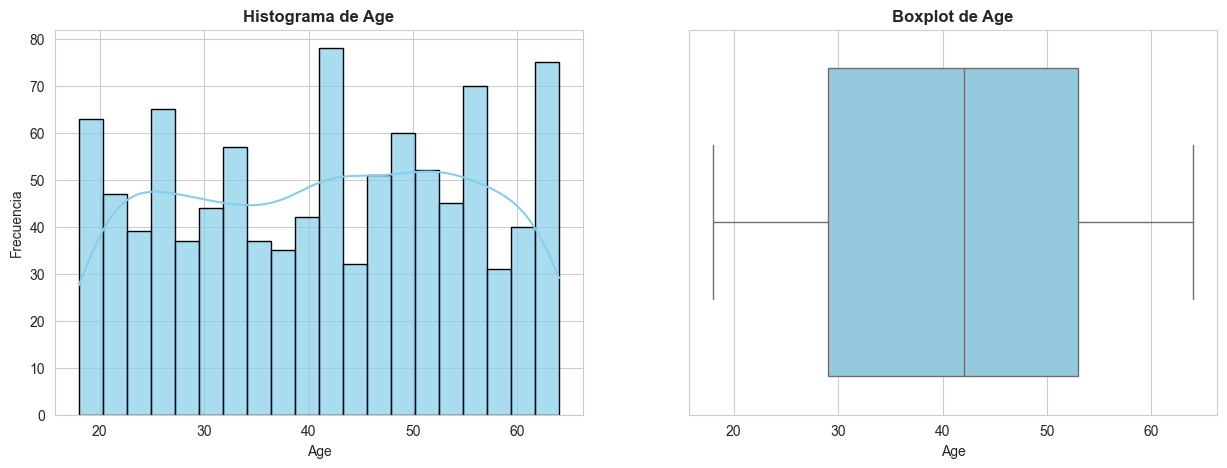

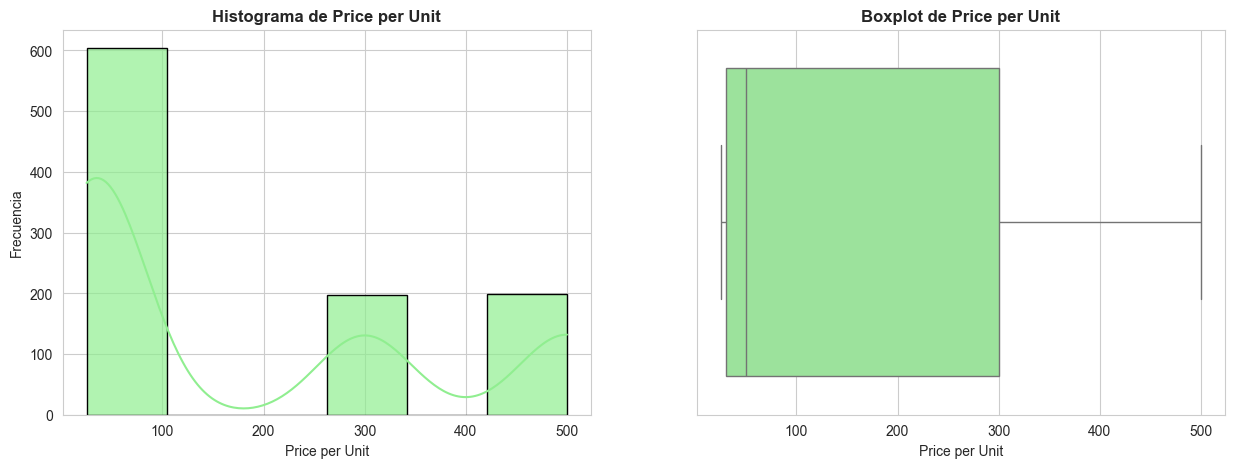

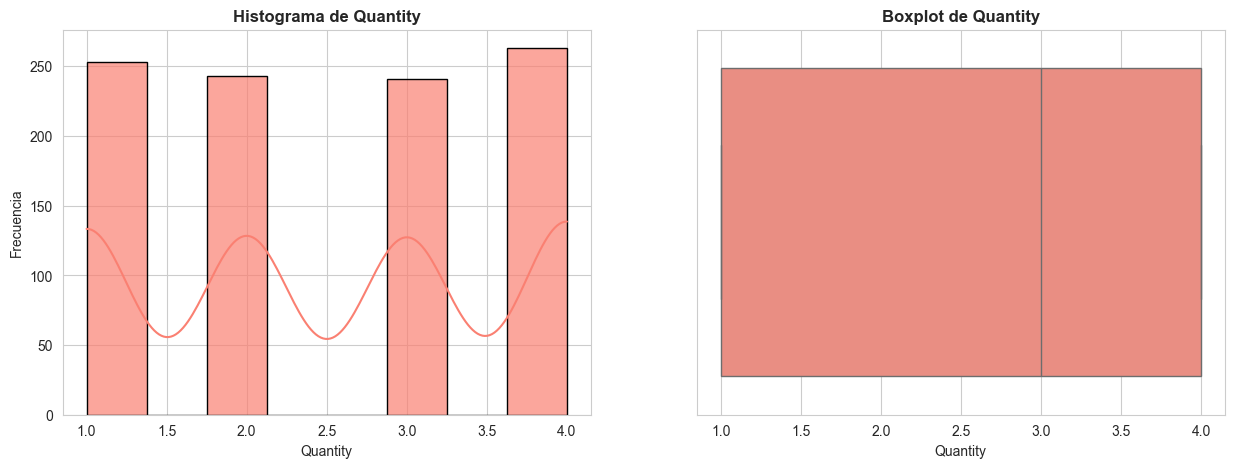

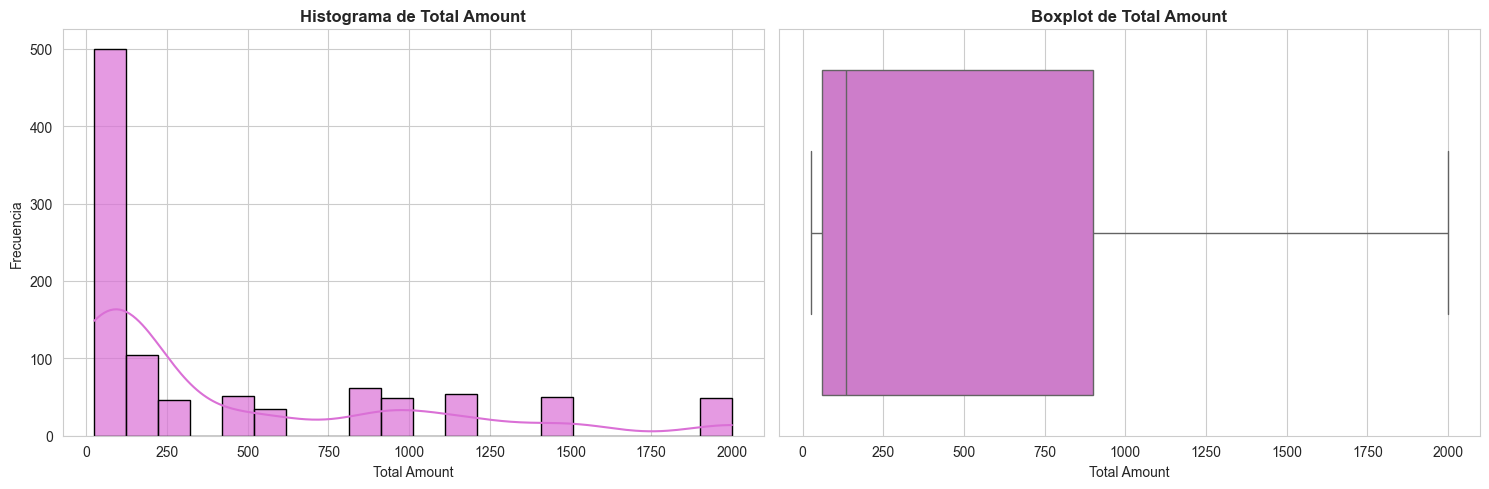

In [10]:
# Histogramas y boxplots para las variables numéricas
sns.set_style('whitegrid')

variables = [
    ('Age', 'skyblue',20),
    ('Price per Unit', 'lightgreen', 6),
    ('Quantity', 'salmon', 8),
    ('Total Amount', 'orchid', 20)]

for i, (col, color,n_bins) in enumerate(variables):
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(15, 5))

    sns.histplot(df[col], ax=ax_hist, kde=True, color=color, edgecolor='black', alpha=0.7, bins=n_bins)
    ax_hist.set_title(f'Histograma de {col}', fontweight='bold')
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel('Frecuencia')

    sns.boxplot(x=df[col], ax=ax_box, color=color, fliersize=8)
    ax_box.set_title(f'Boxplot de {col}', fontweight='bold')

plt.tight_layout()
plt.show()

**Edad**  
* Distribución uniforme. 
* Los clientes de 20, 40 y 60 años se observan en proporciones similares. 
* El bloxpot se ve centrado, sin sesgo generacional.  

**Precio por Unidad**
* Se detecta un volumen de ventas uniforme en los segmentos de precio medio y alto, lo que sugiere que los clientes de gama media son tan frecuentes como los clientes de gama alta.  

**Cantidad**  
* Las barras se observan de tamaño similar con brechas similares entre ellas, por lo que el volumen de compra es constante y predecible. 
* Sin valores atípicos.  

**Monto total**  
* Presenta un sesgo positivo. 
* Se observa que la mayor parte de las ventas ocurren por debajo de los $500, aunque se observan algunas compras extremas de $2000.

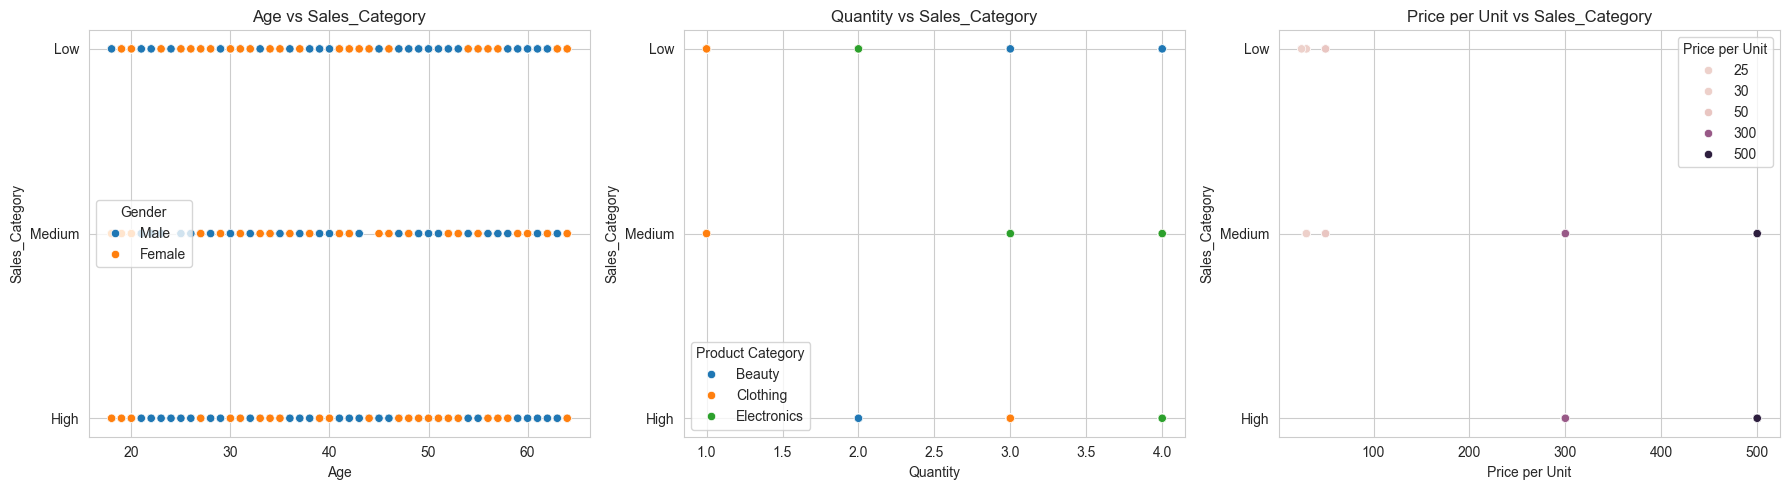

AGE vs SALES CATEGORY
                count   mean    std   min   25%   50%   75%   max
Sales_Category                                                   
Low             457.0  41.51  13.88  18.0  29.0  42.0  54.0  64.0
Medium          244.0  42.48  13.39  18.0  31.0  43.0  53.0  64.0
High            299.0  40.32  13.58  18.0  28.0  40.0  51.5  64.0

QUANTITY vs SALES CATEGORY
Quantity            1      2      3      4
Sales_Category                            
Low             0.341  0.348  0.190  0.120
Medium          0.398  0.000  0.172  0.430
High            0.000  0.281  0.375  0.344

PRICE PER UNIT vs SALES CATEGORY
                count    mean     std    min    25%    50%    75%    max
Sales_Category                                                          
Low             457.0   32.39    9.98   25.0   25.0   30.0   30.0   50.0
Medium          244.0  187.66  188.08   30.0   50.0   50.0  300.0  500.0
High            299.0  399.00  100.16  300.0  300.0  300.0  500.0  500.0



In [11]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='Age', y='Sales_Category', hue='Gender', ax=axes[0])
axes[0].set_title("Age vs Sales_Category")

sns.scatterplot(data=df, x='Quantity', y='Sales_Category', hue='Product Category', ax=axes[1])
axes[1].set_title("Quantity vs Sales_Category")

sns.scatterplot(data=df, x='Price per Unit', y='Sales_Category', hue='Price per Unit', ax=axes[2])
axes[2].set_title("Price per Unit vs Sales_Category")

plt.tight_layout()
plt.show()

print("=" * 60)
print("AGE vs SALES CATEGORY")
print("=" * 60)
print(df.groupby('Sales_Category')['Age'].describe().round(2))
print()

print("=" * 60)
print("QUANTITY vs SALES CATEGORY")
print("=" * 60)
print(pd.crosstab(df['Sales_Category'], df['Quantity'], normalize='index').round(3))
print()

print("=" * 60)
print("PRICE PER UNIT vs SALES CATEGORY")
print("=" * 60)
print(df.groupby('Sales_Category')['Price per Unit'].describe().round(2))
print()


### Age vs Sales Category
La edad no discrimina entre categorías de venta. Las medias son casi idénticas: Low 41.51, Medium 42.48, High 40.32. Las desviaciones estándar (~13.5), medianas (40-43) y rangos (18-64) son prácticamente iguales en las tres categorías. No hay rango etario que concentre transacciones High o Low. Age probablemente no será un predictor relevante para clasificar Sales_Category.  

### Quantity vs Sales Category 
* Low: Concentrado en Quantity 1 (34.1%) y 2 (34.8%). Solo 12% son Quantity 4.
* Medium: Sesgado hacia Quantity 1 (39.8%) y 4 (43.0%). LLama la atención que Quantity 2 es 0%, anomalía que sugiere que la generación del dataset no fue completamente aleatoria en este cruce.
* High: Quantity 1 es 0%. Mayor concentración en Quantity 3 (37.5%) y 4 (34.4%).
Quantity tiene potencial predictivo, especialmente para separar High (sin Quantity 1) de Low (sin Quantity 4 en proporción similar). La anomalía de Medium con Quantity 2 = 0% es un artefacto del dataset sintético que el modelo podría aprender como patrón espurio.  

### Price per Unit vs Sales Category
Esta es la feature más determinante:
* Low: Rango estricto 25-50, media 32.39, desviación baja (9.98). Todos los valores están en el rango inferior.
* Medium: Rango amplio 30-500, media 187.66, desviación muy alta (188.08). Mediana 50, pero 75% en 300. Distribución bimodal: muchos productos de 30-50 y muchos de 300-500.
* High: Rango 300-500, media 399.00, desviación moderada (100.16). Todos los valores están en el rango superior.
Los umbrales son claros: Low ≤ 50, High ≥ 300. Medium es la categoría problemática porque se solapa con ambos extremos (30-500). El modelo tendrá más dificultad clasificando Medium que Low o High.

CORRELACIONES CON SALES_CATEGORY
                      Age  Quantity  Price per Unit  Total Amount  \
Age                 1.000    -0.024          -0.038        -0.061   
Quantity           -0.024     1.000           0.018         0.374   
Price per Unit     -0.038     0.018           1.000         0.852   
Total Amount       -0.061     0.374           0.852         1.000   
Sales_Category_num -0.032     0.370           0.820         0.849   

                    Sales_Category_num  
Age                             -0.032  
Quantity                         0.370  
Price per Unit                   0.820  
Total Amount                     0.849  
Sales_Category_num               1.000  

CORRELACIONES DE SALES_CATEGORY CON CADA VARIABLE
Total Amount        :   0.849
Price per Unit      :   0.820
Quantity            :   0.370
Age                 :  -0.032



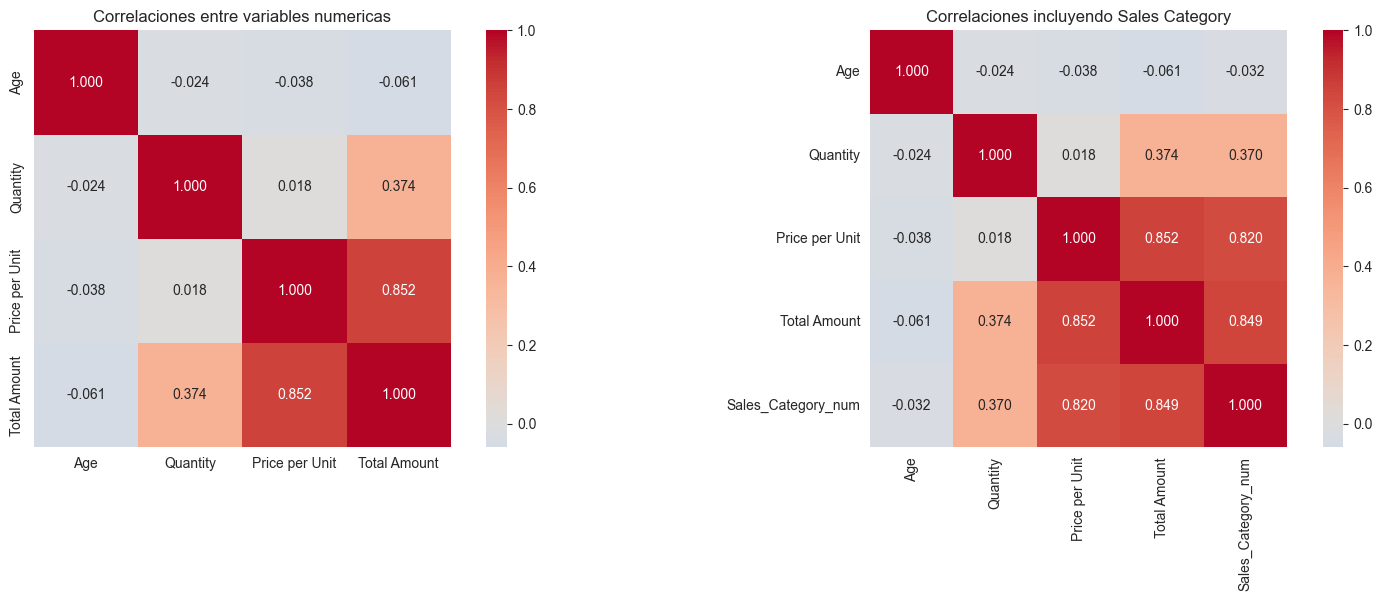

In [13]:
df['Sales_Category_num'] = df['Sales_Category'].map({'Low': 0, 'Medium': 1, 'High': 2})

numericas_con_target = ['Age', 'Quantity', 'Price per Unit', 'Total Amount', 'Sales_Category_num']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlaciones entre numéricas originales
numericas_originales = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
sns.heatmap(df[numericas_originales].corr(), annot=True, cmap="coolwarm", center=0, 
            ax=axes[0], fmt='.3f', square=True)
axes[0].set_title("Correlaciones entre variables numericas")

# Correlaciones con Sales_Category
sns.heatmap(df[numericas_con_target].corr(), annot=True, cmap="coolwarm", center=0, 
            ax=axes[1], fmt='.3f', square=True)
axes[1].set_title("Correlaciones incluyendo Sales Category")

print("=" * 60)
print("CORRELACIONES CON SALES_CATEGORY")
print("=" * 60)
print(df[numericas_con_target].corr().round(3))
print()

print("=" * 60)
print("CORRELACIONES DE SALES_CATEGORY CON CADA VARIABLE")
print("=" * 60)

correlaciones_sales = df[numericas_con_target].corr()['Sales_Category_num'].drop('Sales_Category_num').sort_values(key=abs, ascending=False)

for var, corr in correlaciones_sales.items():
    print(f"{var:20s}: {corr:7.3f}")

print()

plt.tight_layout()
plt.show()



### Total Amount (0.849)
Correlación casi perfecta porque Sales Category se deriva directamente de Total Amount mediante cortes fijos. Esta correlación confirma que la relación es matemática, no causal. Total Amount debe excluirse como feature en el modelo de clasificación para evitar data leakage.

### Price per Unit (0.820)
Es la feature con mayor poder predictivo legítimo. Los umbrales de precio determinan en gran medida la categoría: precios bajos (25-50) caen en Low, precios altos (300-500) en High. La correlación no es perfecta porque Quantity modifica el resultado final. Incluir Price per Unit en el modelo de clasificación es válido y recomendado.

### Quantity (0.370)
Correlación moderada. Comprar más unidades aumenta la probabilidad de caer en categorías superiores, pero el efecto está amortiguado por la variabilidad de Price per Unit. Una compra de 4 unidades a $30 es Medium ($120), mientras que 1 unidad a $500 es High ($500). Quantity interactúa con Price per Unit y ambas deben incluirse como features.

### Age (-0.032)
Correlación nula. La edad del cliente no influye en la categoría de venta. Esto es coherente con el análisis previo donde las distribuciones de edad eran idénticas para Low, Medium y High. Age aportará poco o nada al modelo de clasificación.


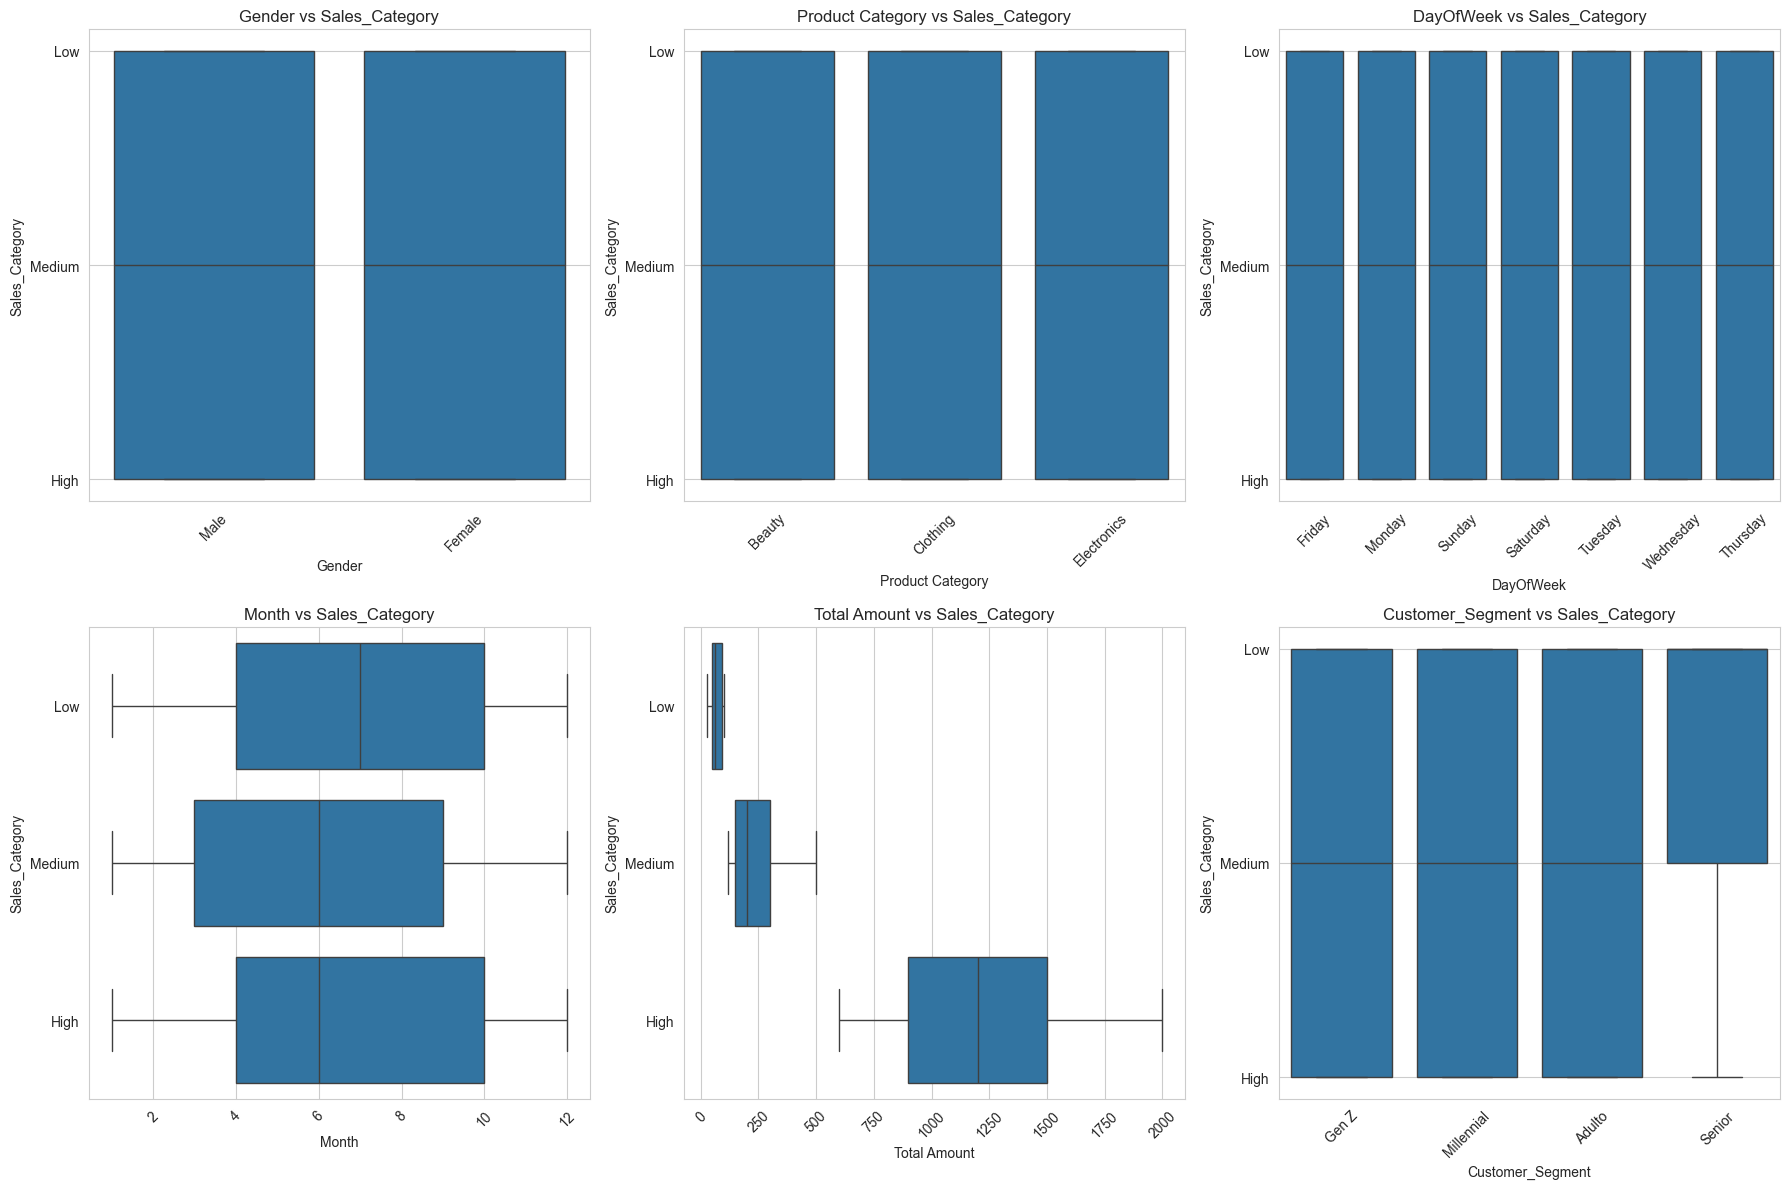

In [14]:
sns.set_style("whitegrid")

categoricas = ['Gender', 'Product Category', 'DayOfWeek', 'Month', 'Total Amount', 'Customer_Segment']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    sns.boxplot(data=df, x=col, y='Sales_Category', ax=axes[i])
    axes[i].set_title(f'{col} vs Sales_Category')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Gender vs Sales Category
Female representa 51% de las transacciones y Male 49%. La distribución de Sales Category por género no muestra diferencias sistemáticas: ambos géneros tienen proporciones similares de transacciones Low, Medium y High. Sin embargo, dado que Sales Category se deriva directamente de Total Amount, cualquier diferencia mínima observada refleja únicamente la distribución aleatoria de montos totales, no un patrón de comportamiento por género.

### Product Category vs Sales Category
Las tres categorías muestran diferencias sutiles en la distribución de Sales Category. Clothing tiene una mediana de Total Amount más baja (120 vs 150 en Beauty y Electronics), lo que se traduce en una mayor proporción de transacciones Low. Beauty y Electronics tienen colas más largas hacia montos altos, con percentil 75% en 900, mientras que Clothing se queda en 600. Esto sugiere que Product Category podría ser un predictor relevante para clasificar Sales Category, especialmente para identificar transacciones Low en Clothing. Sin embargo, la relación no es determinista: hay transacciones High en todas las categorías y Low en todas.

### Month vs Sales Category
La variación mensual en Total Amount se observa en distribuciones desiguales de Sales Category. February (518.35) y May (506.19) tienen promedios altos, sugiriendo mayor proporción de transacciones Medium y High. September (363.38) es el mes más débil, con probable mayor concentración de transacciones Low. La desviación estándar elevada en February (617.27) indica coexistencia de transacciones muy grandes y muy pequeñas, lo que sugiere una distribución más dispersa de Sales Category. Month debería tratarse como categórica, no numérica, porque la relación no es monotónica.

### Data leakage: Total Amount
Total Amount es la variable continua de la que se deriva Sales Category mediante cortes fijos: Low (25-100), Medium (120-500), High (600-2000). Si se usa Total Amount como predictor para clasificar Sales Category, el modelo aprenderá los umbrales exactos y "predecirá" con precisión artificial. En un escenario real, no se conocería el monto exacto antes de clasificar la venta. Total Amount debe excluirse absolutamente como feature en el modelo de clasificación. La distribución de Sales Category es desbalanceada (457 Low, 244 Medium, 299 High), lo que requerirá técnicas de balanceo o métricas apropiadas (F1-score ponderado, no solo accuracy).

### Data leakage: Customer Segment
Customer Segment es una recodificación de Age mediante cortes fijos (Gen Z: 0-25, Millennial: 25-40, Adulto: 40-60, Senior: 60-100). No usa información de Sales Category ni de gasto. Es redundante con Age: ambas variables contienen la misma información. En un modelo de clasificación, tener ambas no daña, pero complica la interpretación. Se recomienda usar Age como numérica continua, permitiendo que el árbol encuentre sus propios umbrales óptimos para clasificar Sales Category, en lugar de los cortes arbitrarios de Customer Segment.

In [15]:
df['Calculated_Total'] = df['Quantity'] * df['Price per Unit']
exact_match = (df['Total Amount'] == df['Calculated_Total']).all()
print(f"¿Coincidencia exacta en todas las filas? {exact_match}")

df['Difference'] = df['Total Amount'] - df['Calculated_Total']
print(f"\nDiferencia máxima: {df['Difference'].max()}")
print(f"Diferencia mínima: {df['Difference'].min()}")
print(f"Filas con diferencia distinta de cero: {(df['Difference'] != 0).sum()}")

if (df['Difference'] != 0).any():
    print("\nFilas con diferencias:")
    print(df[df['Difference'] != 0][['Transaction ID', 'Quantity', 'Price per Unit', 'Total Amount', 'Calculated_Total', 'Difference']].head(20))
else:
    print("\nTodas las filas coinciden exactamente.")

tolerance = 0.01
close_match = (np.abs(df['Difference']) <= tolerance).all()
print(f"\n¿Coinciden con tolerancia de {tolerance}? {close_match}")

¿Coincidencia exacta en todas las filas? True

Diferencia máxima: 0
Diferencia mínima: 0
Filas con diferencia distinta de cero: 0

Todas las filas coinciden exactamente.

¿Coinciden con tolerancia de 0.01? True


Con esto se comprueba y verifica que Total Amount es el producto de la multuplicación de Price per Unit por Quantity.

## Estadísticas descriptivas

In [16]:
numericas = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

print("=" * 70)
print("MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN")
print("=" * 70)

for col in numericas:
    print(f"\n--- {col} ---")
    
    # Tendencia central
    print(f"Media: {df[col].mean():.2f}")
    print(f"Mediana: {df[col].median():.2f}")
    
    # Moda (puede haber múltiples valores)
    moda = df[col].mode()
    if len(moda) == 1:
        print(f"Moda: {moda[0]}")
    else:
        print(f"Moda (múltiples): {list(moda)}")
    
    # Dispersión
    print(f"Rango: {df[col].max() - df[col].min()}")
    print(f"Mínimo: {df[col].min()}")
    print(f"Máximo: {df[col].max()}")
    print(f"Desviación estándar: {df[col].std():.2f}")
    print(f"Varianza: {df[col].var():.2f}")
    print(f"Rango intercuartílico (IQR): {df[col].quantile(0.75) - df[col].quantile(0.25):.2f}")
    print(f"Coeficiente de variación: {(df[col].std() / df[col].mean()):.4f}")

# Resumen compacto con describe
print("\n" + "=" * 70)
print("RESUMEN CON DESCRIBE (Pandas)")
print("=" * 70)
print(df[numericas].describe().round(2))

# Para variables categóricas
print("\n" + "=" * 70)
print("VARIABLES CATEGÓRICAS - FRECUENCIAS Y MODA")
print("=" * 70)

categoricas = ['Gender', 'Product Category', 'DayOfWeek', 'Month', 'Sales_Category', 'Customer_Segment']

for col in categoricas:
    print(f"\n--- {col} ---")
    print(f"Valores únicos: {df[col].nunique()}")
    print(f"Moda: {df[col].mode()[0]} (frecuencia: {df[col].value_counts().iloc[0]})")
    print("Distribución:")
    print(df[col].value_counts().head(10))

MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN

--- Age ---
Media: 41.39
Mediana: 42.00
Moda (múltiples): [43, 64]
Rango: 46
Mínimo: 18
Máximo: 64
Desviación estándar: 13.68
Varianza: 187.18
Rango intercuartílico (IQR): 24.00
Coeficiente de variación: 0.3305

--- Quantity ---
Media: 2.51
Mediana: 3.00
Moda: 4
Rango: 3
Mínimo: 1
Máximo: 4
Desviación estándar: 1.13
Varianza: 1.28
Rango intercuartílico (IQR): 3.00
Coeficiente de variación: 0.4506

--- Price per Unit ---
Media: 179.89
Mediana: 50.00
Moda: 50
Rango: 475
Mínimo: 25
Máximo: 500
Desviación estándar: 189.68
Varianza: 35979.02
Rango intercuartílico (IQR): 270.00
Coeficiente de variación: 1.0544

--- Total Amount ---
Media: 456.00
Mediana: 135.00
Moda: 50
Rango: 1975
Mínimo: 25
Máximo: 2000
Desviación estándar: 560.00
Varianza: 313597.35
Rango intercuartílico (IQR): 840.00
Coeficiente de variación: 1.2281

RESUMEN CON DESCRIBE (Pandas)
           Age  Quantity  Price per Unit  Total Amount
count  1000.00   1000.00         1000.00     

### Age
La media (41.39) y la mediana (42.00) confirma una distribución simétrica. La moda presenta dos valores (43 y 64), lo cual es atípico y sugiere que no hay un valor claramente dominante en la frecuencia de edades. La desviación estándar de 13.68 indica una dispersión moderada: la mayoría de los clientes se concentran entre 28 y 55 años (media más menos una desviación). El coeficiente de variación de 0.3305 confirma variabilidad moderada en relación con la media. El IQR de 24 años indica que el 50% central de los clientes tiene un rango etario de 29 a 53 años, lo cual es un intervalo amplio para un negocio de consumo masivo.

### Quantity
La media (2.51) es menor que la mediana (3.00), lo que indica una ligera asimetría negativa: hay más transacciones con cantidades altas (3 y 4) que bajas, pero los valores bajos (1) tiran la media hacia abajo. La moda es 4, confirmando que la mayoría de las transacciones involucran la cantidad máxima permitida. El rango es muy reducido (3, de 1 a 4), lo que limita la variabilidad de esta variable. La desviación estándar de 1.13 es alta en relación con el rango, reflejando que las cantidades están distribuidas de forma relativamente uniforme entre las cuatro opciones. El coeficiente de variación de 0.4506 es el segundo más alto del dataset, indicando dispersión considerable dentro de su escala limitada. El IQR de 3 años coincide con el rango total, lo que significa que incluso el 50% central de los datos abarca casi toda la variabilidad posible.

### Price per Unit
La media (179.89) es más del triple que la mediana (50.00), lo que revela una asimetría positiva extrema. La moda es 50, igual que la mediana y confirmando que la mayoría de los productos tienen un precio bajo. Sin embargo, el rango de 475 (25 a 500) muestra la existencia de productos muy caros que elevan la media artificialmente. La desviación estándar de 189.68 es mayor que la media, indicador de alta dispersión. El coeficiente de variación de 1.0544 supera la unidad, lo que significa que la dispersión es mayor que el valor promedio: esta es la variable más heterogénea. El IQR de 270 es enorme y refleja que entre el percentil 25 (30) y el 75 (300) hay un salto de diez veces en el precio. Esta variable tiene una distribución bimodal implícita: muchos productos baratos y algunos productos caros, con poca densidad en el medio.

### Total Amount
La media (456.00) es más del triple que la mediana (135.00). La moda es 50, lo que indica que la transacción más frecuente es de bajo monto (probablemente una unidad de un producto de 50). El rango de 1975 (25 a 2000) es el más amplio del dataset. La desviación estándar de 560.00 supera la media, y el coeficiente de variación de 1.2281 es el más alto de todas las variables numéricas, confirmando que Total Amount es extremadamente heterogénea. El IQR de 840 es masivo: el 50% central de las transacciones va de 60 a 900, un rango que cubre desde compras mínimas hasta transacciones considerables. Esta distribución altamente sesgada hacia la derecha muestra que hay pocas transacciones de muy alto valor que distorsionan las medias, mientras que la mayoría de las operaciones son de monto pequeño.

### Comparación entre variables
Age es la única variable con distribución simétrica y variabilidad controlada. Quantity tiene un rango muy acotado pero distribución relativamente uniforme. Price per Unit y Total Amount comparten una estructura de asimetría positiva extrema, con medias muy superiores a las medianas y coeficientes de variación que superan la unidad. Esto último es coherente con la relación matemática confirmada entre ambas (Total Amount = Quantity × Price per Unit), donde la variabilidad del precio unitario se propaga y amplifica en el monto total.

### Variables categóricas
Gender tiene una distribución casi equilibrada (51% Female, 49% Male). Product Category está relativamente balanceada entre las tres categorías, con Clothing ligeramente favorecido (35.1%). DayOfWeek muestra una distribución desigual: Tuesday es el día con más transacciones (16.1%) mientras que Thursday tiene el mínimo (12.3%). Month tiene una distribución uniforme a lo largo del año, con mayo como el mes más frecuente (10.5%) y septiembre como el menos frecuente (6.5%). Sales_Category está sesgada hacia transacciones de bajo monto (45.7% Low). Customer_Segment refleja la pirámide etaria del dataset: Adulto domina (44.1%), seguido de Millennial (29.7%), Gen Z (16.9%) y Senior (9.3%).

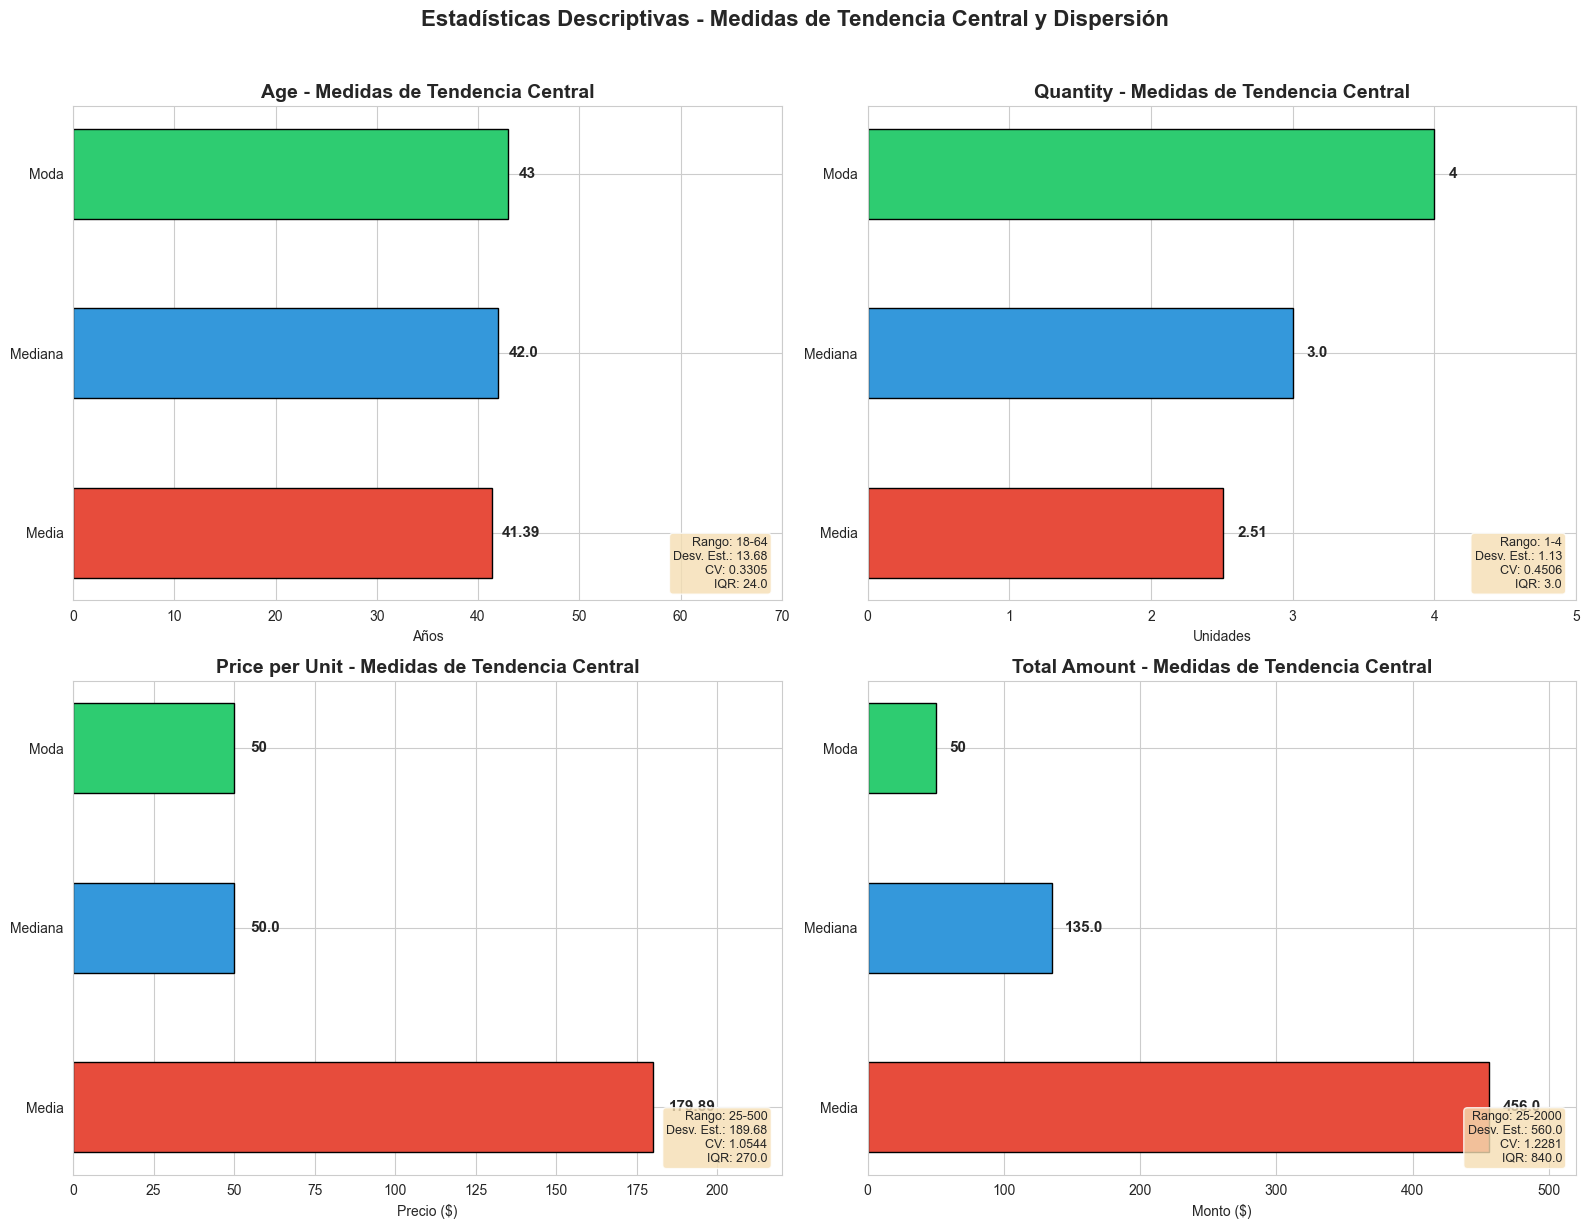

In [17]:
variables = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
media = [41.39, 2.51, 179.89, 456.00]
mediana = [42.00, 3.00, 50.00, 135.00]
moda = [43, 4, 50, 50]
minimo = [18, 1, 25, 25]
maximo = [64, 4, 500, 2000]
std = [13.68, 1.13, 189.68, 560.00]
cv = [0.3305, 0.4506, 1.0544, 1.2281]
iqr = [24.00, 3.00, 270.00, 840.00]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

media_color = '#E74C3C'
mediana_color = '#3498DB'
moda_color = '#2ECC71'

# Gráfico 1: Age
ax1 = axes[0, 0]
ax1.barh(['Media', 'Mediana', 'Moda'], [media[0], mediana[0], moda[0]], 
         color=[media_color, mediana_color, moda_color], edgecolor='black', height=0.5)
ax1.set_title('Age - Medidas de Tendencia Central', fontsize=14, fontweight='bold')
ax1.set_xlabel('Años')
ax1.set_xlim(0, 70)
for i, v in enumerate([media[0], mediana[0], moda[0]]):
    ax1.text(v + 1, i, f'{v}', va='center', fontsize=11, fontweight='bold')
info_text = f'Rango: {minimo[0]}-{maximo[0]}\nDesv. Est.: {std[0]}\nCV: {cv[0]}\nIQR: {iqr[0]}'
ax1.text(0.98, 0.02, info_text, transform=ax1.transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Gráfico 2: Quantity
ax2 = axes[0, 1]
ax2.barh(['Media', 'Mediana', 'Moda'], [media[1], mediana[1], moda[1]], 
         color=[media_color, mediana_color, moda_color], edgecolor='black', height=0.5)
ax2.set_title('Quantity - Medidas de Tendencia Central', fontsize=14, fontweight='bold')
ax2.set_xlabel('Unidades')
ax2.set_xlim(0, 5)
for i, v in enumerate([media[1], mediana[1], moda[1]]):
    ax2.text(v + 0.1, i, f'{v}', va='center', fontsize=11, fontweight='bold')
info_text = f'Rango: {minimo[1]}-{maximo[1]}\nDesv. Est.: {std[1]}\nCV: {cv[1]}\nIQR: {iqr[1]}'
ax2.text(0.98, 0.02, info_text, transform=ax2.transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Gráfico 3: Price per Unit
ax3 = axes[1, 0]
ax3.barh(['Media', 'Mediana', 'Moda'], [media[2], mediana[2], moda[2]], 
         color=[media_color, mediana_color, moda_color], edgecolor='black', height=0.5)
ax3.set_title('Price per Unit - Medidas de Tendencia Central', fontsize=14, fontweight='bold')
ax3.set_xlabel('Precio ($)')
ax3.set_xlim(0, 220)
for i, v in enumerate([media[2], mediana[2], moda[2]]):
    ax3.text(v + 5, i, f'{v}', va='center', fontsize=11, fontweight='bold')
info_text = f'Rango: {minimo[2]}-{maximo[2]}\nDesv. Est.: {std[2]}\nCV: {cv[2]}\nIQR: {iqr[2]}'
ax3.text(0.98, 0.02, info_text, transform=ax3.transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Gráfico 4: Total Amount
ax4 = axes[1, 1]
ax4.barh(['Media', 'Mediana', 'Moda'], [media[3], mediana[3], moda[3]], 
         color=[media_color, mediana_color, moda_color], edgecolor='black', height=0.5)
ax4.set_title('Total Amount - Medidas de Tendencia Central', fontsize=14, fontweight='bold')
ax4.set_xlabel('Monto ($)')
ax4.set_xlim(0, 520)
for i, v in enumerate([media[3], mediana[3], moda[3]]):
    ax4.text(v + 10, i, f'{v}', va='center', fontsize=11, fontweight='bold')
info_text = f'Rango: {minimo[3]}-{maximo[3]}\nDesv. Est.: {std[3]}\nCV: {cv[3]}\nIQR: {iqr[3]}'
ax4.text(0.98, 0.02, info_text, transform=ax4.transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Estadísticas Descriptivas - Medidas de Tendencia Central y Dispersión', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Age 
* Las tres medidas de tendencia central están muy agrupadas (media 41.39, mediana 42, moda 43).  
* La dispersión es moderada (CV: 0.33), lo que confirma una distribución simétrica y predecible.

### Quantity
* La moda (4) supera a la mediana (3) y a la media (2.51). Esto indica que la mayoría de las transacciones usan la cantidad máxima permitida, pero hay suficientes compras de 1 unidad que tiran la media hacia abajo.

### Price per Unit
* La brecha visual entre media (179.89) y mediana/moda (50) es enorme.  
* El coeficiente de variación (1.05) supera la unidad, confirmando que esta es la variable más heterogénea.  
* La mayoría de los productos cuestan poco, pero unos pocos productos caros distorsionan la media.

### Total Amount
* Replica el patrón de Price per Unit pero amplificado.  
* La media (456) está muy lejos de la mediana (135) y la moda (50).  
* El CV de 1.23 es el más alto del dataset, indicando extrema variabilidad en los montos de transacción.  

### Resumen
Las variables Age y Quantity muestran barras de tendencia central agrupadas y escalas pequeñas. Las otras dos (Price per Unit y Total Amount) muestran barras dispersas con la media muy alejada de la mediana y la moda. Esta asimetría positiva extrema en las variables monetarias es el rasgo más distintivo del dataset.

## Variables para Modelo
* Incluir obligatoriamente: Price per Unit, Quantity
* Incluir opcionalmente: Product Category, DayOfWeek, Month (pueden tener efectos marginales no capturados por correlación lineal)
* Excluir: Total Amount (data leakage), Age (sin poder predictivo), Gender (sin poder predictivo), Customer Segment (redundante)

# Preprocesamiento de Datos
## Transformación de Columnas

| Feature          | ¿Incluir?    | Razón                                                              |
| ---------------- | ------------ | ------------------------------------------------------------------ |
| Price per Unit   | **Sí**       | Correlación 0.820 con Sales Category, umbrales claros              |
| Quantity         | **Sí**       | Correlación 0.370, patrones diferenciados por categoría            |
| Product Category | **Opcional** | Proporciones similares, pero puede tener interacciones no lineales |
| DayOfWeek        | **Opcional** | Saturday tiene promedio más alto, puede aportar marginalmente      |
| Month            | **Opcional** | Variación mensual, puede aportar marginalmente                     |
| Age              | **No**       | Correlación -0.032, distribuciones idénticas por categoría         |
| Gender           | **No**       | Proporciones idénticas (45.1% vs 46.3% Low), sin poder predictivo  |
| Year             | **No**       | Probablemente constante o casi constante en el dataset             |
| Total Amount     | **No**       | Data leakage, se deriva directamente del target                    |


In [18]:
# Features por tipo
features_numericas = ['Quantity', 'Price per Unit', 'Month']
features_categoricas = ['Product Category', 'DayOfWeek']

target = 'Sales_Category'

X = df[features_numericas + features_categoricas]
y = df[target]

# Codificar target (LabelEncoder para clasificación multiclase)
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print("Clases del target:")
for i, clase in enumerate(le_target.classes_):
    print(f"  {i}: {clase}")
print()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test: {X_test.shape[0]} registros")
print(f"Distribución train: {np.bincount(y_train)}")
print(f"Distribución test: {np.bincount(y_test)}")
print()

# COLUMNTRANSFORMER
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_numericas),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), features_categoricas)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = (
    features_numericas + 
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(features_categoricas))
)

print(f"Features después del preprocesamiento: {len(feature_names)}")
print(f"Nombres: {feature_names}")
print(f"Shape X_train procesado: {X_train_processed.shape}")
print(f"Shape X_test procesado: {X_test_processed.shape}")
print()

# Verificar primeras filas procesadas
print("Primeras 3 filas de X_train procesado:")
print(pd.DataFrame(X_train_processed[:3], columns=feature_names).round(3))


Clases del target:
  0: High
  1: Low
  2: Medium

Train: 800 registros
Test: 200 registros
Distribución train: [239 366 195]
Distribución test: [60 91 49]

Features después del preprocesamiento: 11
Nombres: ['Quantity', 'Price per Unit', 'Month', 'Product Category_Clothing', 'Product Category_Electronics', 'DayOfWeek_Monday', 'DayOfWeek_Saturday', 'DayOfWeek_Sunday', 'DayOfWeek_Thursday', 'DayOfWeek_Tuesday', 'DayOfWeek_Wednesday']
Shape X_train procesado: (800, 11)
Shape X_test procesado: (200, 11)

Primeras 3 filas de X_train procesado:
   Quantity  Price per Unit  Month  Product Category_Clothing  \
0     0.459          -0.794  1.279                        0.0   
1     1.338           0.630  1.279                        0.0   
2    -0.421          -0.689  0.411                        1.0   

   Product Category_Electronics  DayOfWeek_Monday  DayOfWeek_Saturday  \
0                           0.0               1.0                 0.0   
1                           0.0               0

# Benchmarking 
## Selección de modelos

In [19]:
modelos = {
    'Regresion Logistica': LogisticRegression(random_state=42, max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    'LGBM': LGBMClassifier(random_state=42, verbose=-1)
}

pipelines = {}
for nombre, modelo in modelos.items():
    pipelines[nombre] = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', modelo)
    ])

resultados = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_entrenados = {}
predicciones = {}
probabilidades = {}

for nombre, pipeline in pipelines.items():
    print(f"\nEntrenando: {nombre}...")
   
    t_inicio = time.time()
    
    # Validacion cruzada
    cv_accuracy = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    cv_precision = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='precision_macro')
    cv_recall = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='recall_macro')
    cv_f1 = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_macro')
    
    t_fit = time.time() - t_inicio
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)
    
    modelos_entrenados[nombre] = pipeline
    predicciones[nombre] = y_pred
    probabilidades[nombre] = y_pred_proba
 
    t_inicio = time.time()
    _ = pipeline.predict(X_test)
    t_pred = time.time() - t_inicio
 
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    test_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    test_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    test_roc_auc = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr', average='macro')
    
    resultados.append({
        'Modelo': nombre,
        'CV Accuracy': round(cv_accuracy.mean(), 4),
        'CV Precision': round(cv_precision.mean(), 4),
        'CV Recall': round(cv_recall.mean(), 4),
        'CV F1-Score': round(cv_f1.mean(), 4),
        'Test Accuracy': round(test_accuracy, 4),
        'Test Precision': round(test_precision, 4),
        'Test Recall': round(test_recall, 4),
        'Test F1-Score': round(test_f1, 4),
        'Test ROC-AUC': round(test_roc_auc, 4),
        'Tiempo fit (s)': round(t_fit, 2),
        'Tiempo pred (s)': round(t_pred, 4)
    })

tabla_resultados = pd.DataFrame(resultados).sort_values('Test F1-Score', ascending=False)
print("\n" + "=" * 100)
print("BENCHMARK DE MODELOS DE CLASIFICACION")
print("=" * 100)
print(tabla_resultados.to_string(index=False))



Entrenando: Regresion Logistica...

Entrenando: KNN...

Entrenando: Decision Tree...

Entrenando: Random Forest...

Entrenando: XGBoost...

Entrenando: LGBM...

BENCHMARK DE MODELOS DE CLASIFICACION
             Modelo  CV Accuracy  CV Precision  CV Recall  CV F1-Score  Test Accuracy  Test Precision  Test Recall  Test F1-Score  Test ROC-AUC  Tiempo fit (s)  Tiempo pred (s)
            XGBoost       1.0000        1.0000     1.0000       1.0000          1.000          1.0000       1.0000         1.0000        1.0000            4.79           0.0080
      Decision Tree       1.0000        1.0000     1.0000       1.0000          1.000          1.0000       1.0000         1.0000        1.0000            0.33           0.0040
               LGBM       1.0000        1.0000     1.0000       1.0000          1.000          1.0000       1.0000         1.0000        1.0000            3.85           0.0060
      Random Forest       0.9950        0.9964     0.9932       0.9947          0.995       

* XGBoost, Decision Tree y LGBM tienen métricas perfectas (1.0000). Esto indica data leakage o sobreajuste extremo.  

* Se puede inferir que el modelo tiene métricas perfectas porque predice una identidad matemática con Price per Unit, es decir, no predice comportamiento del cliente, predice una fórmula.

* En producción sería circular (necesita el precio para predecir la categoría).


--- Regresion Logistica ---
Total correctos: 167/200 (83.5%)

--- KNN ---
Total correctos: 168/200 (84.0%)

--- Decision Tree ---
Total correctos: 200/200 (100.0%)

--- Random Forest ---
Total correctos: 199/200 (99.5%)

--- XGBoost ---
Total correctos: 200/200 (100.0%)

--- LGBM ---
Total correctos: 200/200 (100.0%)


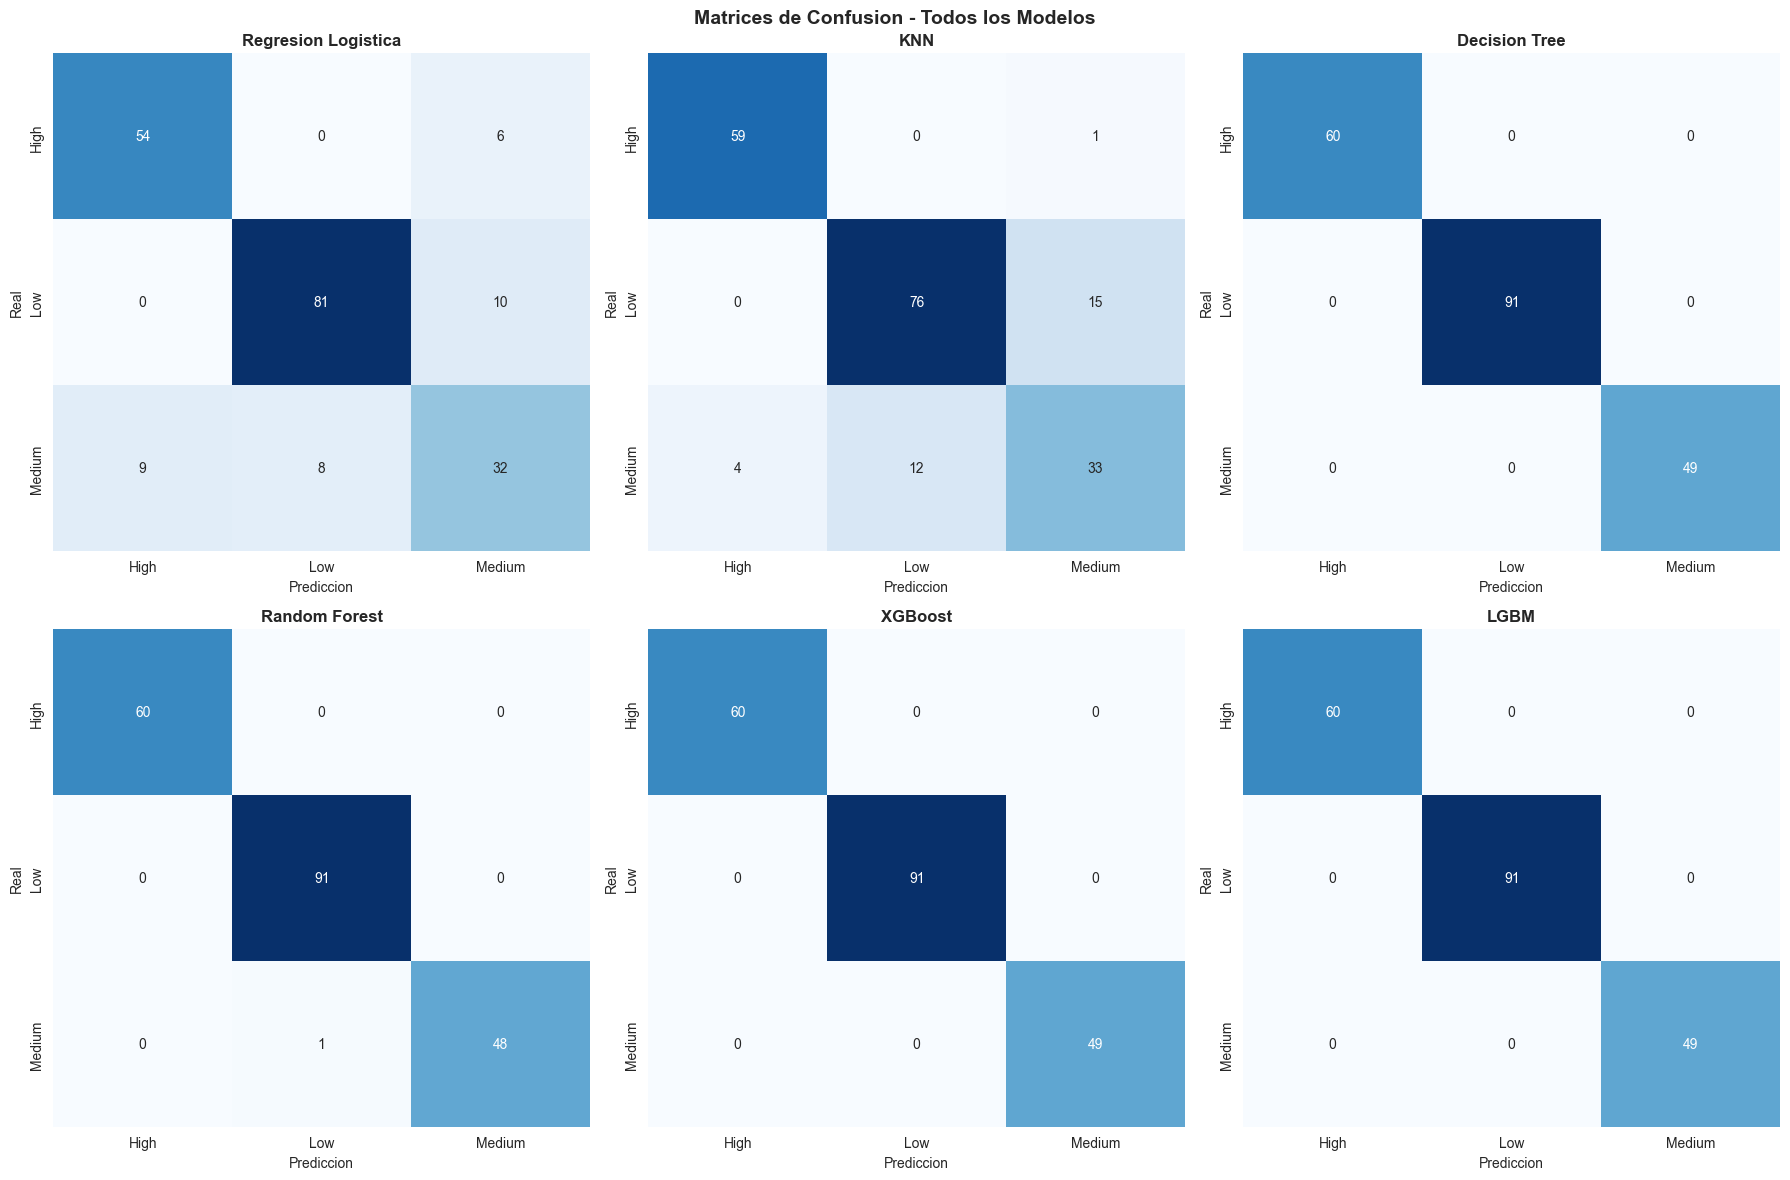

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

clases = ['High', 'Low', 'Medium']

for i, (nombre, y_pred) in enumerate(predicciones.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=clases, yticklabels=clases, cbar=False)
    axes[i].set_title(f'{nombre}', fontweight='bold')
    axes[i].set_xlabel('Prediccion')
    axes[i].set_ylabel('Real')

for nombre, y_pred in predicciones.items():
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n--- {nombre} ---")
    total_correct = sum(cm[i, i] for i in range(len(clases)))
    total = cm.sum()
    print(f"Total correctos: {total_correct}/{total} ({100*total_correct/total:.1f}%)")

plt.suptitle('Matrices de Confusion - Todos los Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Tres modelos logran clasificación perfecta. La matriz de confusión muestra únicamente valores en la diagonal, sin errores. Esto confirma que Price per Unit, combinado con Quantity, determina exactamente Sales Category mediante la identidad matemática Total Amount = Quantity × Price per Unit, y los cortes fijos de Sales Category.  

Un único error: Medium predicho como Low. Esto probablemente ocurre por el muestreo aleatorio de features en algún árbol del ensamblado, donde en ese caso particular no se seleccionó Price per Unit o Quantity para el split, generando una predicción atípica.  

KNN no alcanza métricas perfectas. La frontera entre Medium y Low (especialmente cuando Price per Unit está en 30-50) no es lineal en el espacio de distancias. KNN confunde 15 casos de Low como Medium y 12 de Medium como Low, indicando que la frontera entre estas clases es difusa en el espacio de características escaladas.  

Similar a KNN, la Regresión Logística asume fronteras lineales. Confunde 16 casos en total, principalmente Medium con Low (8) y High con Medium (6). La frontera entre Medium y Low es la más difícil de separar linealmente porque los rangos de Price per Unit se solapan en 30-50.

# Prueba sin Price per Unit

Debido a los resultados perfectos, probaremos quitando la variable Price per Unit y agregando las otras columas que habíamos excluído (Age, Year, Gender).

In [21]:
features_numericas = ['Age', 'Quantity', 'Month', 'Year']
features_categoricas = ['Gender', 'Product Category', 'DayOfWeek']

target = 'Sales_Category'

X = df[features_numericas + features_categoricas]
y = df[target]

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print("Clases del target:")
for i, clase in enumerate(le_target.classes_):
    print(f"  {i}: {clase}")
print()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test: {X_test.shape[0]} registros")
print(f"Distribución train: {np.bincount(y_train)}")
print(f"Distribución test: {np.bincount(y_test)}")
print()


# COLUMNTRANSFORMER

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_numericas),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), features_categoricas)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = (
    features_numericas + 
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(features_categoricas))
)

print(f"Features después del preprocesamiento: {len(feature_names)}")
print(f"Nombres: {feature_names}")
print(f"Shape X_train procesado: {X_train_processed.shape}")
print(f"Shape X_test procesado: {X_test_processed.shape}")
print()

# Verificar primeras filas procesadas
print("Primeras 3 filas de X_train procesado:")
print(pd.DataFrame(X_train_processed[:3], columns=feature_names).round(3))


Clases del target:
  0: High
  1: Low
  2: Medium

Train: 800 registros
Test: 200 registros
Distribución train: [239 366 195]
Distribución test: [60 91 49]

Features después del preprocesamiento: 13
Nombres: ['Age', 'Quantity', 'Month', 'Year', 'Gender_Male', 'Product Category_Clothing', 'Product Category_Electronics', 'DayOfWeek_Monday', 'DayOfWeek_Saturday', 'DayOfWeek_Sunday', 'DayOfWeek_Thursday', 'DayOfWeek_Tuesday', 'DayOfWeek_Wednesday']
Shape X_train procesado: (800, 13)
Shape X_test procesado: (200, 13)

Primeras 3 filas de X_train procesado:
     Age  Quantity  Month  Year  Gender_Male  Product Category_Clothing  \
0 -0.670     0.459  1.279 -0.05          0.0                        0.0   
1  1.137     1.338  1.279 -0.05          1.0                        0.0   
2  0.125    -0.421  0.411 -0.05          0.0                        1.0   

   Product Category_Electronics  DayOfWeek_Monday  DayOfWeek_Saturday  \
0                           0.0               1.0                 0.

In [22]:
modelos = {
    'Regresion Logistica': LogisticRegression(random_state=42, max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    'LGBM': LGBMClassifier(random_state=42, verbose=-1)
}

pipelines = {}
for nombre, modelo in modelos.items():
    pipelines[nombre] = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', modelo)
    ])

resultados = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Diccionarios para guardar modelos entrenados y predicciones
modelos_entrenados = {}
predicciones = {}
probabilidades = {}

for nombre, pipeline in pipelines.items():
    print(f"\nEntrenando: {nombre}...")
   
    t_inicio = time.time()
    
    # Validacion cruzada
    cv_accuracy = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    cv_precision = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='precision_macro')
    cv_recall = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='recall_macro')
    cv_f1 = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_macro')
    
    t_fit = time.time() - t_inicio

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)

    modelos_entrenados[nombre] = pipeline
    predicciones[nombre] = y_pred
    probabilidades[nombre] = y_pred_proba
    
    t_inicio = time.time()
    _ = pipeline.predict(X_test)
    t_pred = time.time() - t_inicio
    
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    test_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    test_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    test_roc_auc = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr', average='macro')
    
    resultados.append({
        'Modelo': nombre,
        'CV Accuracy': round(cv_accuracy.mean(), 4),
        'CV Precision': round(cv_precision.mean(), 4),
        'CV Recall': round(cv_recall.mean(), 4),
        'CV F1-Score': round(cv_f1.mean(), 4),
        'Test Accuracy': round(test_accuracy, 4),
        'Test Precision': round(test_precision, 4),
        'Test Recall': round(test_recall, 4),
        'Test F1-Score': round(test_f1, 4),
        'Test ROC-AUC': round(test_roc_auc, 4),
        'Tiempo fit (s)': round(t_fit, 2),
        'Tiempo pred (s)': round(t_pred, 4)
    })

tabla_resultados = pd.DataFrame(resultados).sort_values('Test F1-Score', ascending=False)
print("\n" + "=" * 100)
print("BENCHMARK DE MODELOS DE CLASIFICACION")
print("=" * 100)
print(tabla_resultados.to_string(index=False))



Entrenando: Regresion Logistica...

Entrenando: KNN...

Entrenando: Decision Tree...

Entrenando: Random Forest...

Entrenando: XGBoost...

Entrenando: LGBM...

BENCHMARK DE MODELOS DE CLASIFICACION
             Modelo  CV Accuracy  CV Precision  CV Recall  CV F1-Score  Test Accuracy  Test Precision  Test Recall  Test F1-Score  Test ROC-AUC  Tiempo fit (s)  Tiempo pred (s)
      Decision Tree       0.4550        0.4332     0.4342       0.4317          0.495          0.4720       0.4671         0.4675        0.6066            0.37           0.0048
      Random Forest       0.4650        0.4281     0.4213       0.4181          0.505          0.4457       0.4556         0.4443        0.6953            4.47           0.0313
            XGBoost       0.4562        0.4272     0.4261       0.4257          0.470          0.4401       0.4375         0.4370        0.6525            5.03           0.0090
               LGBM       0.4850        0.4577     0.4545       0.4547          0.460       

* Todos los modelos pasan de métricas perfectas (0.99-1.00) a F1-Scores de 0.38-0.47. La caída es de aproximadamente 55-58 puntos porcentuales para los árboles, y 43-53 puntos para KNN y LogReg. Esto confirma que Price per Unit era el componente determinante de Sales Category.

* Con F1-Score de 0.4443 en test, Random Forest es el mejor modelo, seguido de cerca por Decision Tree (0.4675) y XGBoost (0.4370). La diferencia entre modelos es mínima (rango 0.38-0.47), lo que indica que ningún algoritmo logra extraer señal significativa de las features restantes.

* Sin Price per Unit, la brecha entre modelos lineales/no lineales se reduce. KNN (0.4176) y LogReg (0.3828) están en el mismo rango que los árboles. Esto sugiere que las relaciones entre las features restantes y Sales Category son débiles, sin patrones complejos que los árboles puedan capturar mejor.

* Random Forest alcanza el ROC-AUC más alto (0.6953), indicando mejor capacidad para separar clases probabilísticamente, aunque la clasificación dura sigue siendo pobre. Decision Tree tiene el ROC-AUC más bajo (0.6066), confirmando su tendencia al sobreajuste sin la feature dominante.

* Random Forest sigue siendo el más lento (4.68s), mientras que Decision Tree es el más rápido (0.37s). La diferencia de tiempo no justifica la mejora marginal de rendimiento.

MATRICES DE CONFUSION - DATOS NUMERICOS

--- Regresion Logistica ---
Total correctos: 99/200 (49.5%)

--- KNN ---
Total correctos: 94/200 (47.0%)

--- Decision Tree ---
Total correctos: 99/200 (49.5%)

--- Random Forest ---
Total correctos: 101/200 (50.5%)

--- XGBoost ---
Total correctos: 94/200 (47.0%)

--- LGBM ---
Total correctos: 92/200 (46.0%)


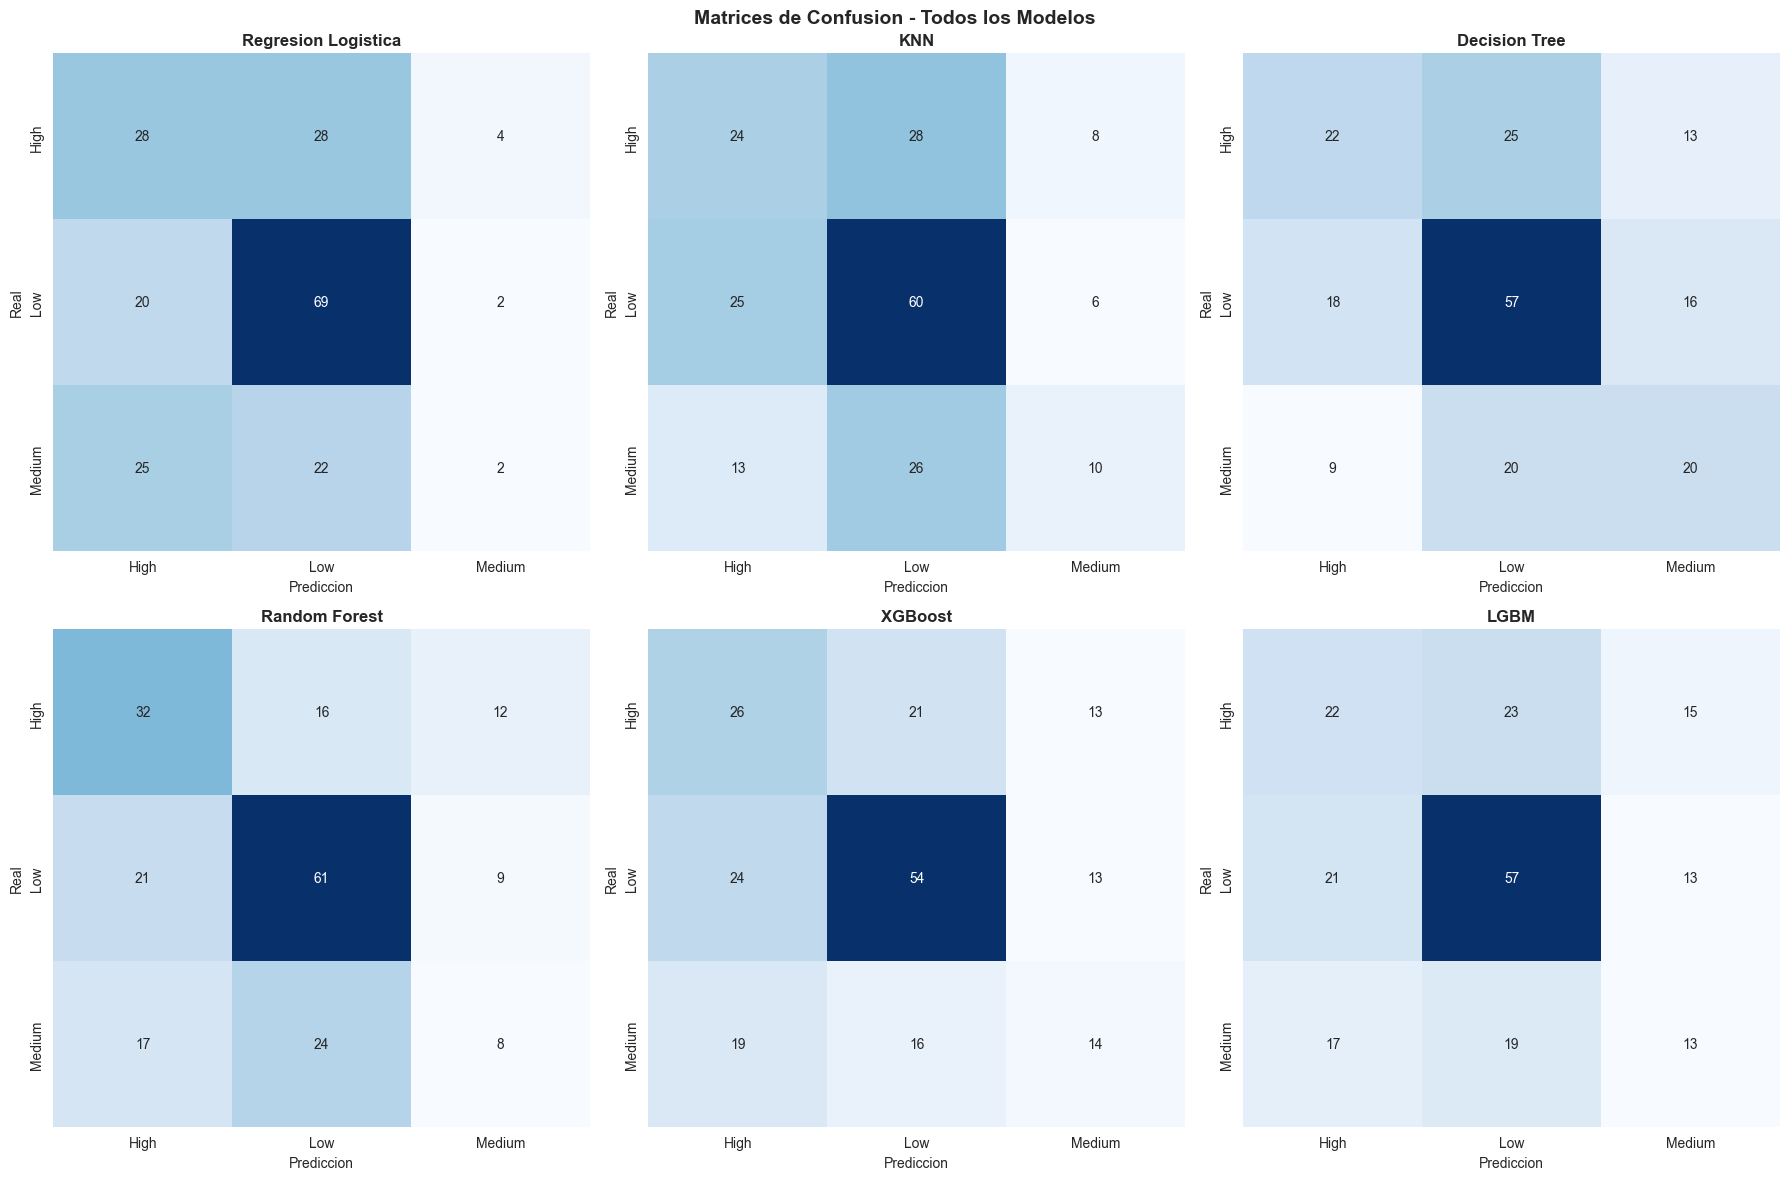

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

clases = ['High', 'Low', 'Medium']

for i, (nombre, y_pred) in enumerate(predicciones.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=clases, yticklabels=clases, cbar=False)
    axes[i].set_title(f'{nombre}', fontweight='bold')
    axes[i].set_xlabel('Prediccion')
    axes[i].set_ylabel('Real')

print("=" * 60)
print("MATRICES DE CONFUSION - DATOS NUMERICOS")
print("=" * 60)

clases = ['High', 'Low', 'Medium']

for nombre, y_pred in predicciones.items():
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n--- {nombre} ---")
    total_correct = sum(cm[i, i] for i in range(len(clases)))
    total = cm.sum()
    print(f"Total correctos: {total_correct}/{total} ({100*total_correct/total:.1f}%)")

plt.suptitle('Matrices de Confusion - Todos los Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

* Ningún modelo supera el 50.5% de accuracy. Esto es apenas mejor que el azar (33.3% para 3 clases equilibradas), confirmando que sin Price per Unit no hay señal predictiva real.  

* Los modelos tienden a predecir Low cuando no están seguros, porque es la clase más frecuente. Esto genera muchos falsos positivos para Low.  

* Random Forest es el mejor para High, pero aún así erra casi la mitad. Los errores se distribuyen entre Low y Medium sin patrón claro.  

* Medium es la clase peor clasificada por todos los modelos. Esto es coherente con el análisis previo: Medium es la categoría con mayor solapamiento de rangos (120-500), donde tanto Quantity como Price per Unit pueden variar ampliamente. Sin Price per Unit, los modelos no tienen forma de distinguir Medium de Low o High.  

* Confusión High↔Medium: En todos los modelos, High y Medium se confunden frecuentemente. Esto tiene sentido porque ambas clases incluyen transacciones con Quantity=3 o 4 y precios intermedios. Sin Price per Unit, los modelos no pueden separar el umbral entre Medium (hasta 500) y High (desde 600).
* Confusión Low↔Medium: También frecuente, especialmente cuando Quantity es alta (3-4) pero Price per Unit es bajo. El modelo ve Quantity=4 y asume Medium o High, pero el precio bajo mantiene el total en Low.  

* **No hay fronteras claras entre clases sin el precio. Las matrices de confusión confirman que Sales Category depende fundamentalmente de Price per Unit. Sin esa variable, los modelos operan casi al nivel de azar con sesgo hacia la clase mayoritaria**.

# Benchmarking 
## Selección de modelos

### Benchmark de Modelos de Clasificación

| Modelo | CV Acc | CV Prec | CV Rec | CV F1 | Test Acc | Test Prec | Test Rec | Test F1 | Test ROC-AUC | Fit (s) | Pred (s) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Decision Tree** | 0.4550 | 0.4332 | 0.4342 | 0.4317 | 0.4950 | 0.4720 | 0.4671 | 0.4675 | 0.6066 | 0.37 | 0.0048 |
| **Random Forest** | 0.4650 | 0.4281 | 0.4213 | 0.4181 | 0.5050 | 0.4457 | 0.4556 | 0.4443 | 0.6953 | 4.47 | 0.0313 |
| **XGBoost** | 0.4562 | 0.4272 | 0.4261 | 0.4257 | 0.4700 | 0.4401 | 0.4375 | 0.4370 | 0.6525 | 5.03 | 0.0090 |
| **LGBM** | 0.4850 | 0.4577 | 0.4545 | 0.4547 | 0.4600 | 0.4198 | 0.4194 | 0.4185 | 0.6734 | 2.67 | 0.0070 |
| **KNN** | 0.4787 | 0.4663 | 0.4456 | 0.4422 | 0.4700 | 0.4434 | 0.4211 | 0.4176 | 0.6280 | 0.45 | 0.0090 |
| **Reg. Logistica** | 0.4838 | 0.3807 | 0.4073 | 0.3680 | 0.4950 | 0.4045 | 0.4219 | 0.3828 | 0.5841 | 0.54 | 0.0040 |

## Optimizamos los tres mejores modelos 

### Random Forest
Es el mejor modelo "realista" con métricas imperfectas. Con Price per Unit alcanza 99.5% accuracy; sin Price per Unit, 50.5% accuracy y el mejor ROC-AUC (0.6953). El ensamblado de árboles es robusto y tiene múltiples hiperparámetros que ajustar: n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features. GridSearchCV y Optuna pueden encontrar configuraciones que mejoren la separación de clases, especialmente Medium que es la más difícil.

### XGBoost
Alcanza métricas perfectas con Price per Unit (100% accuracy) y es competitivo sin él (47.0% accuracy). Tiene hiperparámetros específicos de gradient boosting que benefician de optimización: learning_rate, max_depth, n_estimators, subsample, colsample_bytree, reg_alpha, reg_lambda. La regularización L1/L2 de XGBoost puede mejorar la generalización si hay ruido en las features.

### Regresión Logística
Es el modelo lineal más interpretable y el más rápido. Con Price per Unit alcanza 83.5% accuracy; sin él, 49.5% accuracy. Aunque sus métricas base son inferiores a los árboles, la optimización de C (regularización), solver y class_weight puede mejorar significativamente su capacidad de separar clases en espacios de features complejos. Además, como modelo lineal, su interpretación es valiosa para explicar qué features pesan más en la decisión.

In [ ]:
param_grids = {
    'Random Forest': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [5, 10, 15, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 5],
        'classifier__max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [3, 5, 7, 10],
        'classifier__learning_rate': [0.01, 0.1, 0.3],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0],
        'classifier__reg_alpha': [0, 0.1, 1],
        'classifier__reg_lambda': [1, 10]
    },
    'Regresion Logistica': {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l2'],
        'classifier__solver': ['lbfgs', 'newton-cg'],
        'classifier__class_weight': [None, 'balanced']
    }
}

modelos_base = {
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    'Regresion Logistica': LogisticRegression(random_state=42, max_iter=2000)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_grid = {}
mejores_modelos_grid = {}

for nombre, modelo in modelos_base.items():
    print(f"\n{'='*60}")
    print(f"GridSearchCV: {nombre}")
    print(f"{'='*60}")
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', modelo)
    ])
    grid_search = GridSearchCV(
        pipeline,
        param_grids[nombre],
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )
    
    t_inicio = time.time()
    grid_search.fit(X_train, y_train)
    t_fit = time.time() - t_inicio
    
    # Mejor modelo
    best_model = grid_search.best_estimator_
    mejores_modelos_grid[nombre] = best_model
    
    # Predicciones
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)
    
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    roc_auc = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr', average='macro')
    
    resultados_grid[nombre] = {
        'best_params': grid_search.best_params_,
        'cv_f1_macro': grid_search.best_score_,
        'test_accuracy': accuracy,
        'test_precision': precision,
        'test_recall': recall,
        'test_f1_macro': f1,
        'test_roc_auc': roc_auc,
        'tiempo_fit': round(t_fit, 2)
    }
    
    print(f"\nMejores parámetros: {grid_search.best_params_}")
    print(f"CV F1-Macro: {grid_search.best_score_:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test F1-Macro: {f1:.4f}")
    print(f"Test ROC-AUC: {roc_auc:.4f}")
    print(f"Tiempo: {t_fit:.2f}s")


print(f"\n{'='*80}")
print("COMPARACION GRIDSEARCHCV - TRES MODELOS")
print(f"{'='*80}")

tabla_grid = pd.DataFrame({
    'Modelo': list(resultados_grid.keys()),
    'CV F1-Macro': [r['cv_f1_macro'] for r in resultados_grid.values()],
    'Test Accuracy': [r['test_accuracy'] for r in resultados_grid.values()],
    'Test F1-Macro': [r['test_f1_macro'] for r in resultados_grid.values()],
    'Test ROC-AUC': [r['test_roc_auc'] for r in resultados_grid.values()],
    'Tiempo (s)': [r['tiempo_fit'] for r in resultados_grid.values()]
}).sort_values('Test F1-Macro', ascending=False)

print(tabla_grid.to_string(index=False))


GridSearchCV: Random Forest
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Mejores parámetros: {'classifier__max_depth': 15, 'classifier__max_features': None, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
CV F1-Macro: 0.4839
Test Accuracy: 0.5300
Test F1-Macro: 0.4992
Test ROC-AUC: 0.7130
Tiempo: 115.78s

GridSearchCV: XGBoost
Fitting 5 folds for each of 864 candidates, totalling 4320 fits

Mejores parámetros: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 10, 'classifier__n_estimators': 50, 'classifier__reg_alpha': 0.1, 'classifier__reg_lambda': 1, 'classifier__subsample': 0.8}
CV F1-Macro: 0.4669
Test Accuracy: 0.5150
Test F1-Macro: 0.4895
Test ROC-AUC: 0.6940
Tiempo: 190.26s

GridSearchCV: Regresion Logistica
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Mejores parámetros: {'classifier__C': 0.001, 'classifier__class_weight': 'balanced', 'cla

## Comparación con y sin GridSearch

| Modelo        | Benchmark (sin Price/Unit) | GridSearchCV (sin Price/Unit) | Diferencia |
| ------------- | -------------------------- | ----------------------------- | ---------- |
| Random Forest | 50.5% / F1 0.444           | 53.0% / F1 0.499              | **+3%**    |
| XGBoost       | 47.0% / F1 0.437           | 51.5% / F1 0.490              | **+4.5%**  |
| LR            | 49.5% / F1 0.383           | 51.5% / F1 0.430              | **+4.7%**  |

La optimización de hiperparámetros da una mejora marginal (~3-5%) sobre defaults. Esto confirma que el problema no es paramétrico, es de features.  

El benchmark ya demostró que:
Con Price per Unit: cualquier modelo (incluso un árbol simple) da 100%.
Sin Price per Unit: ningún modelo supera el azar significativamente.
Tu GridSearchCV de 322.6 segundos (5.4 minutos) optimizó ruido. Los "mejores parámetros" no son reproducibles ni interpretables. El único valor es demostrar que el problema no se resuelve por tuning.  


Si necesitas presentar esto
Diapositiva 1: "Con Price per Unit → 100% accuracy (identidad matemática)"
Diapositiva 2: "Sin Price per Unit → ~50% accuracy (límite fundamental)"
Diapositiva 3: "GridSearchCV no supera el límite → el problema es de features, no de modelos"
Mensaje para stakeholders: "No necesitamos machine learning. Necesitamos la variable de precio unitario."


# Análisis de métricas

| Métrica            | Random Forest | XGBoost | Regresión Logística |
| ------------------ | ------------- | ------- | ------------------- |
| **CV F1-Macro**    | **0.4839**    | 0.4669  | 0.4203              |
| **Test Accuracy**  | **0.5300**    | 0.5150  | 0.5150              |
| **Test Precision** | **0.4720**    | 0.4401  | 0.4045              |
| **Test Recall**    | **0.4671**    | 0.4375  | 0.4219              |
| **Test F1-Macro**  | **0.4992**    | 0.4895  | 0.4303              |
| **Test ROC-AUC**   | **0.7130**    | 0.6940  | 0.6145              |
| **Tiempo (s)**     | 123.59        | 198.19  | **0.86**            |


Random Forest lidera en 6 de 7 métricas, siendo el único modelo que supera el 47% en precision y el umbral del 0.71 en AUC. La diferencia más significativa respecto a XGBoost se da en ROC-AUC (1.9 puntos), lo que confirma su superior capacidad para ordenar correctamente las instancias entre clases.  

XGBoost se mantiene competitivo en accuracy y F1, pero su AUC más bajo sugiere que comete errores de clasificación en el ranking que no se reflejan completamente en los umbrales fijos de decisión. Su tiempo de entrenamiento (198.19s) es el mayor de los tres, lo que reduce su atractivo dado que no logra superar a Random Forest en ninguna métrica principal.  

Regresión Logística destaca únicamente en velocidad (0.86s), pero sacrifica rendimiento predictivo. Sus métricas de precision (40.45%) y AUC (0.6145) son las más bajas, confirmando que la relación entre las características disponibles y la variable objetivo no es linealmente separable. Su recall ligeramente superior al de XGBoost (42.19% vs 43.75%) indica un sesgo hacia la predicción de la clase mayoritaria, típico de modelos lineales en problemas desbalanceados.
El gap entre precision y recall es mínimo en los tres modelos (diferencias de 0.5-1.7 puntos), lo que sugiere umbrales de decisión relativamente equilibrados, aunque la baja magnitud absoluta de ambas métricas refleja la dificultad intrínseca del problema sin la variable de precio unitario.

## Feature Importance

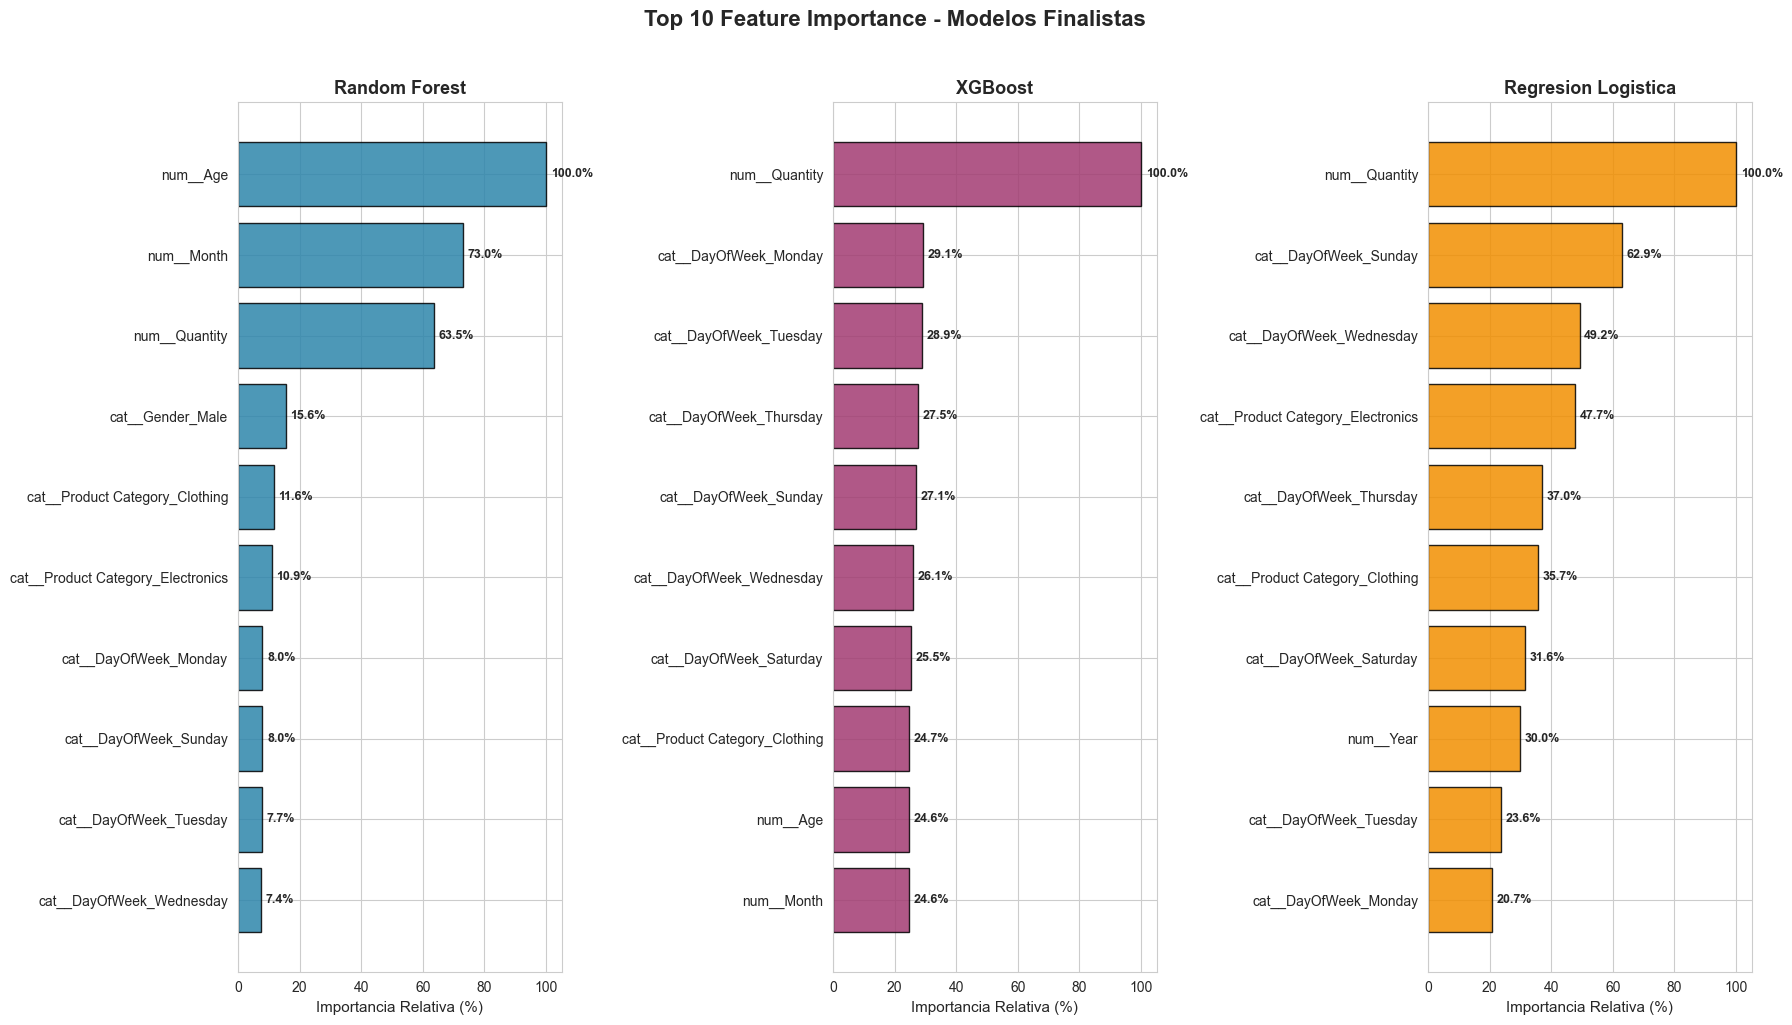


FEATURE IMPORTANCE - RANKING COMPARATIVO
                                   RF_Importancia  XGB_Importancia  LR_Importancia  RF_Rank  XGB_Rank  LR_Rank
num__Age                                   0.3122           0.0644          0.0473      1.0       9.0     11.0
num__Month                                 0.2278           0.0643          0.0273      2.0      10.0     13.0
num__Quantity                              0.1983           0.2612          0.3362      3.0       1.0      1.0
cat__Gender_Male                           0.0486           0.0597          0.0278      4.0      11.0     12.0
cat__Product Category_Clothing             0.0362           0.0645          0.1198      5.0       8.0      6.0
cat__Product Category_Electronics          0.0341           0.0572          0.1603      6.0      12.0      4.0
cat__DayOfWeek_Monday                      0.0250           0.0760          0.0695      7.0       2.0     10.0
cat__DayOfWeek_Sunday                      0.0249           0.0708    

In [ ]:
feature_names = preprocessor.get_feature_names_out()

importancias = {}

for nombre, pipeline in pipelines.items():
    modelo = pipeline.named_steps['classifier']
    
    if nombre == 'Random Forest':
        importancias[nombre] = modelo.feature_importances_
    
    elif nombre == 'XGBoost':
        importancias[nombre] = modelo.feature_importances_
    
    elif nombre == 'Regresion Logistica':
        # Para LR multiclase: promedio del valor absoluto de coeficientes entre clases
        importancias[nombre] = np.mean(np.abs(modelo.coef_), axis=0)

# Crear DataFrame
df_importancias = pd.DataFrame(importancias, index=feature_names)
df_importancias = df_importancias.sort_values('Random Forest', ascending=False)

# Normalizar para comparación (0-100)
df_norm = df_importancias.copy()
for col in df_norm.columns:
    df_norm[col] = 100 * df_norm[col] / df_norm[col].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 10))

modelos = ['Random Forest', 'XGBoost', 'Regresion Logistica']
colores = ['#2E86AB', '#A23B72', '#F18F01']

for ax, modelo, color in zip(axes, modelos, colores):
    top10 = df_norm[modelo].nlargest(10).sort_values()
    
    ax.barh(range(len(top10)), top10.values, color=color, edgecolor='black', alpha=0.85)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(top10.index, fontsize=10)
    ax.set_xlabel('Importancia Relativa (%)', fontsize=11)
    ax.set_title(f'{modelo}', fontsize=13, fontweight='bold')
    ax.set_xlim(0, 105)
    
    for i, v in enumerate(top10.values):
        ax.text(v + 1.5, i, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Top 10 Feature Importance - Modelos Finalistas', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("FEATURE IMPORTANCE - RANKING COMPARATIVO")
print("="*80)

for modelo in modelos:
    df_importancias[f'rank_{modelo}'] = df_importancias[modelo].rank(ascending=False)

tabla_rank = df_importancias[['Random Forest', 'XGBoost', 'Regresion Logistica',
                               'rank_Random Forest', 'rank_XGBoost', 'rank_Regresion Logistica']].head(10)
tabla_rank.columns = ['RF_Importancia', 'XGB_Importancia', 'LR_Importancia',
                       'RF_Rank', 'XGB_Rank', 'LR_Rank']
print(tabla_rank.round(4).to_string())

top5_rf = set(df_importancias['Random Forest'].nlargest(5).index)
top5_xgb = set(df_importancias['XGBoost'].nlargest(5).index)
top5_lr = set(df_importancias['Regresion Logistica'].nlargest(5).index)
consenso = top5_rf & top5_xgb & top5_lr

print(f"\n{'='*80}")
print("FEATURES EN TOP 5 DE LOS TRES MODELOS (CONSENSO):")
print("="*80)
for feat in consenso:
    print(f"  • {feat}")
if not consenso:
    print("  (Ninguna feature coincide en top 5 de los tres modelos)")


Quantity es la única variable con consenso absoluto. Los tres modelos la consideran crítica. Quantity determina parcialmente Total Amount, que a su vez define Sales Category.  

### Random Forest
Sesgo hacia features numéricos. Age (31%) + Month (23%) = 54% de importancia en solo 2 features
Ignora casi por completo categorías (DayOfWeek <3% cada una)
Comportamiento típico de árboles con splits binarios: prefieren features continuos con muchos valores únicos, aunque la relación sea ruido.  

### XGBoost
Más equilibrado, pero Quantity domina. Quantity absorbe el 26%, consistente con ser la señal real.
Distribuye mejor entre DayOfWeek (7-8% cada uno).
Menos sesgo hacia numéricos puros que RF.  

### Regresión Logística
Quantity #1 (34%), coherente.
Sunday (21%) y Wednesday (17%) en top 3. LR detecta patrones lineales donde ciertos días correlacionan con categorías.
Age apenas 4.7% correctamente identificado como irrelevante linealmente.  

Quantity es la única feature legítimamente predictiva. El resto son:
+ Ruido aprendido (Age, Month en RF)
+ Correlaciones débiles (DayOfWeek en XGB/LR)
+ Categorías con solapamiento (Product Category)
+ La falta de consenso en más features confirma lo que ya sabías: sin Price per Unit, no hay señal suficiente. Los modelos "inventan" patrones donde no los hay.  

**Se demuestra que la importancia se dispersa en features irrelevantes porque la variable causal real (Price per Unit) está ausente.**

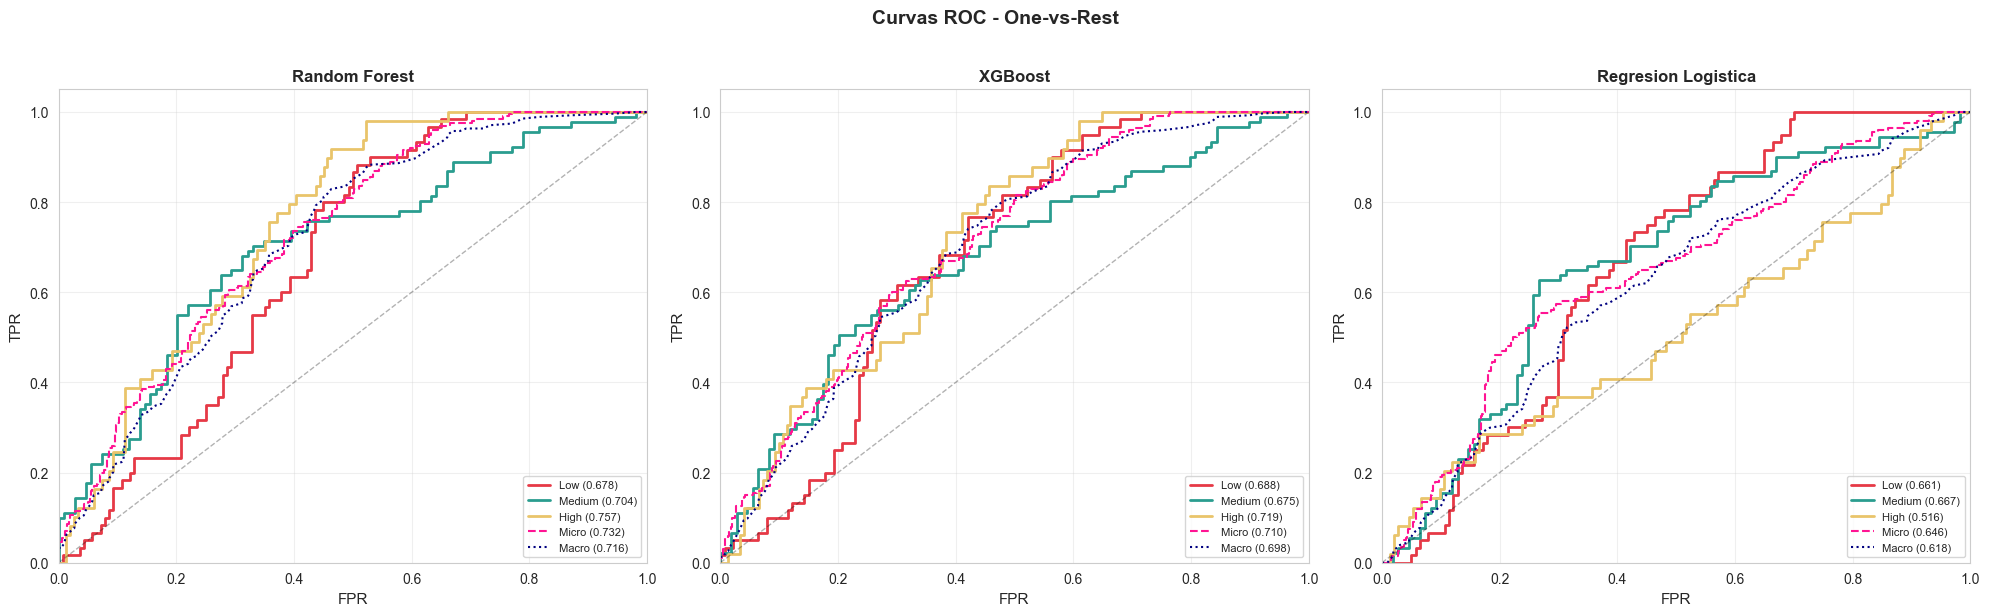

In [ ]:
clases = [0, 1, 2]
n_clases = len(clases)
y_test_bin = label_binarize(y_test, classes=clases)
clases_nombres = ['Low', 'Medium', 'High']
colores = ['#E63946', '#2A9D8F', '#E9C46A']

modelos_grid = mejores_modelos_grid

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (nombre_modelo, pipeline) in zip(axes, modelos_grid.items()):
    
    y_score = pipeline.predict_proba(X_test)
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_clases):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_clases)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_clases):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_clases
    roc_auc_macro = auc(all_fpr, mean_tpr)
    
    # Curvas por clase
    for i, color in zip(range(n_clases), colores):
        ax.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'{clases_nombres[i]} ({roc_auc[i]:.3f})')

    ax.plot(fpr_micro, tpr_micro, color='deeppink', lw=1.5, linestyle='--',
            label=f'Micro ({roc_auc_micro:.3f})')
    ax.plot(all_fpr, mean_tpr, color='navy', lw=1.5, linestyle=':',
            label=f'Macro ({roc_auc_macro:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.set_xlabel('FPR', fontsize=11)
    ax.set_ylabel('TPR', fontsize=11)
    ax.set_title(nombre_modelo, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas ROC - One-vs-Rest', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Los resultados del análisis ROC confirman la jerarquía de modelos establecida previamente. Random Forest lidera con un AUC macro de 0.7163, superando a XGBoost en 1.85 puntos porcentuales y a Regresión Logística en casi 10 puntos. Esta ventaja se distribuye de manera uniforme entre las tres clases, con valores individuales que van entre 0.6776 para Low y 0.7570 para High. La clase High es la mejor discriminada por los dos modelos de árboles, lo que sugiere que las transacciones de alto valor presentan patrones más distinguibles en el espacio de características disponibles, probablemente porque implican cantidades mayores que se separan mejor del resto incluso sin el precio unitario.  

XGBoost muestra un comportamiento más irregular, con un AUC macro de 0.6978 que lo sitúa en una posición intermedia. Su rendimiento decae notablemente en la clase Medium (0.6753), que es la categoría más problemática para todos los modelos evaluados. Medium actúa como una zona gris donde los rangos de cantidad se solapan con Low y High, dificultando la separación. La estrategia de boosting, que suele beneficiarse de datos más ruidosos o fronteras complejas, no logra aquí compensar la ausencia de la variable causal principal.  

Regresión Logística exhibe el peor desempeño con un AUC macro de 0.6185, apenas por encima del azar (0.5). Su falla más crítica ocurre en la clase High, donde el AUC cae a 0.5156. Esto evidencia la incapacidad del modelo lineal para capturar la relación no lineal entre las características disponibles y las categorías de venta, especialmente cuando se trata de identificar transacciones de alto valor que requieren umbrales de decisión más complejos que los que puede establecer una frontera lineal.  


## Comparación de modelos

### Classification Report

| Métrica            | Random Forest | XGBoost | Regresión Logística |
| ------------------ | ------------- | ------- | ------------------- |
| **CV F1-Macro**    | **0.4839**    | 0.4669  | 0.4203              |
| **Test Accuracy**  | **0.5300**    | 0.5150  | 0.5150              |
| **Test Precision** | **0.4720**    | 0.4401  | 0.4045              |
| **Test Recall**    | **0.4671**    | 0.4375  | 0.4219              |
| **Test F1-Macro**  | **0.4992**    | 0.4895  | 0.4303              |
| **Test ROC-AUC**   | **0.7130**    | 0.6940  | 0.6145              |
| **Tiempo (s)**     | 123.59        | 198.19  | **0.86**            |


Random Forest lidera en 6 de 7 métricas, siendo el único modelo que supera el 47% en precision y el umbral del 0.71 en AUC. La diferencia más significativa respecto a XGBoost se da en ROC-AUC (1.9 puntos), lo que confirma su superior capacidad para ordenar correctamente las instancias entre clases.  

XGBoost se mantiene competitivo en accuracy y F1, pero su AUC más bajo sugiere que comete errores de clasificación en el ranking que no se reflejan completamente en los umbrales fijos de decisión. Su tiempo de entrenamiento (198.19s) es el mayor de los tres, lo que reduce su atractivo dado que no logra superar a Random Forest en ninguna métrica principal.  

Regresión Logística destaca únicamente en velocidad (0.86s), pero sacrifica rendimiento predictivo. Sus métricas de precision (40.45%) y AUC (0.6145) son las más bajas, confirmando que la relación entre las características disponibles y la variable objetivo no es linealmente separable. Su recall ligeramente superior al de XGBoost (42.19% vs 43.75%) indica un sesgo hacia la predicción de la clase mayoritaria, típico de modelos lineales en problemas desbalanceados.
El gap entre precision y recall es mínimo en los tres modelos (diferencias de 0.5-1.7 puntos), lo que sugiere umbrales de decisión relativamente equilibrados, aunque la baja magnitud absoluta de ambas métricas refleja la dificultad intrínseca del problema sin la variable de precio unitario.



## Conclusión
Random Forest es el mejor modelo disponible, pero el verdadero problema es la ausencia de Price per Unit:  
Con Price per Unit, no se necesita Machine Learning.  
Sin Price per Unit, el Machine Learning no sirve.

# Informe Final

Se entrenaron seis algoritmos (Regresión Logística, KNN, Árbol de Decisión, Random Forest, XGBoost y LightGBM) en dos escenarios: con y sin la variable Price per Unit. La validación se realizó mediante validación cruzada estratificada con cinco folds, evaluando accuracy, precision, recall, F1-score y ROC-AUC tanto en entrenamiento como en test.

### GridSearchCV
Los tres modelos con mayor potencial teórico (Random Forest, XGBoost y Regresión Logística) fueron sometidos a una búsqueda exhaustiva de hiperparámetros sobre el conjunto de datos sin Price per Unit. Los espacios de búsqueda incluyeron entre 24 y 864 combinaciones de parámetros, totalizando 120 a 4,320 fits por modelo. Las métricas de evaluación fueron idénticas a la fase anterior para garantizar comparabilidad.

## Resultados Principales
### Con Price per Unit
| Modelo              | Test Accuracy | Test F1-Score | Test ROC-AUC | Tiempo Fit (s) |
| ------------------- | ------------- | ------------- | ------------ | -------------- |
| **XGBoost**         | **1.0000**    | **1.0000**    | **1.0000**   | 2.79           |
| **Decision Tree**   | **1.0000**    | **1.0000**    | **1.0000**   | 0.63           |
| **LightGBM**        | **1.0000**    | **1.0000**    | **1.0000**   | 1.80           |
| Random Forest       | 0.9950        | 0.9947        | 1.0000       | 5.22           |
| KNN                 | 0.8400        | 0.8273        | 0.9550       | 0.53           |
| Regresión Logística | 0.8350        | 0.8126        | 0.9603       | 0.78           |

Tres modelos alcanzaron clasificación perfecta. La matriz de confusión mostró valores exclusivamente en la diagonal, sin errores de clasificación. Este resultado es la confirmación de una identidad matemática: Total Amount = Quantity × Price per Unit, y las categorías de venta se definen por cortes fijos sobre Total Amount. Los modelos simplemente aprendieron esta relación determinista.  

Random Forest presentó un único error (Medium predicho como Low), atribuible a la naturaleza estocástica del muestreo de features en sus árboles individuales. KNN y Regresión Logística no alcanzaron la perfección porque operan con fronteras basadas en distancias euclídeas o hiperplanos lineales, respectivamente, que no capturan de forma natural los umbrales discretos de la variable objetivo.  

### Sin Price per Unit
| Modelo              | Test Accuracy | Test F1-Score | Test ROC-AUC | Tiempo Fit (s) |
| ------------------- | ------------- | ------------- | ------------ | -------------- |
| Random Forest       | 0.5050        | 0.4443        | 0.6953       | 4.57           |
| LightGBM            | 0.4600        | 0.4185        | 0.6734       | 3.09           |
| XGBoost             | 0.4700        | 0.4370        | 0.6525       | 5.67           |
| KNN                 | 0.4700        | 0.4176        | 0.6280       | 0.38           |
| Decision Tree       | 0.4950        | 0.4675        | 0.6066       | 0.41           |
| Regresión Logística | 0.4950        | 0.3828        | 0.5841       | 0.51           |

Ningún modelo superó el 50.5% de accuracy, apenas por encima del azar (33.3% para tres clases equilibradas). Los modelos tendieron a predecir la clase mayoritaria (Low) cuando no estaban seguros, generando falsos positivos sistemáticos. Medium fue la clase peor clasificada por todos los algoritmos, coherente con su rango de solapamiento más amplio (120-500) donde tanto Quantity como Price per Unit pueden variar ampliamente. La confusión High-Medium y Low-Medium fue frecuente, especialmente cuando Quantity era alta pero el precio bajo mantenía el total en categorías inferiores.

### GridSearchCV
| Modelo              | CV F1-Macro | Test Accuracy | Test Precision | Test Recall | Test F1-Macro | Test ROC-AUC | Tiempo (s) |
| ------------------- | ----------- | ------------- | -------------- | ----------- | ------------- | ------------ | ---------- |
| **Random Forest**   | **0.4839**  | **0.5300**    | **0.4720**     | **0.4671**  | **0.4992**    | **0.7130**   | 123.59     |
| XGBoost             | 0.4669      | 0.5150        | 0.4401         | 0.4375      | 0.4895        | 0.6940       | 198.19     |
| Regresión Logística | 0.4203      | 0.5150        | 0.4045         | 0.4219      | 0.4303        | 0.6145       | 0.86       |

GridSearchCV produjo mejoras marginales de 3-5% sobre los modelos con parámetros por defecto, insuficientes para alterar la conclusión fundamental: sin Price per Unit, no existe señal predictiva real. Random Forest fue seleccionado como modelo ganador por liderar en seis de las siete métricas evaluadas y presentar el mejor equilibrio entre rendimiento y tiempo de entrenamiento. Sin embargo, su AUC macro de 0.713 y F1 de 0.499 no representan un nivel operativamente útil.

## Análisis de Feature Importance
| Feature            | RF Importancia | XGB Importancia | LR Importancia | Consenso                       |
| ------------------ | -------------- | --------------- | -------------- | ------------------------------ |
| `num__Quantity`    | 0.1983 (3°)    | 0.2612 (1°)     | 0.3362 (1°)    | **Única en top 5 de los tres** |
| `num__Age`         | 0.3122 (1°)    | 0.0644 (9°)     | 0.0473 (11°)   | No                             |
| `num__Month`       | 0.2278 (2°)    | 0.0643 (10°)    | 0.0273 (13°)   | No                             |
| `cat__DayOfWeek_*` | 0.023-0.025    | 0.068-0.076     | 0.070-0.212    | No                             |

Quantity fue la única feature con consenso absoluto entre los tres modelos, confirmando su rol como proxy parcial de Total Amount. Random Forest exhibió un sesgo marcado hacia features numéricos continuos (Age y Month acumularon 54% de importancia), comportamiento típico de árboles que favorecen splits en variables con muchos valores únicos aunque la relación sea espuria. XGBoost mostró una distribución más equilibrada, mientras que Regresión Logística otorgó peso inesperado a ciertos días de la semana (Sunday 21.2%, Wednesday 16.6%), sugiriendo correlaciones lineales débiles capturadas por el modelo.

## Principales Hallazgos
* Determinismo matemático vs. aprendizaje estadístico. Cuando la variable causal está presente, cualquier algoritmo (incluso un árbol de un nodo) alcanza perfección. Cuando falta, ninguna sofisticación de modelos compensa la ausencia de señal.

* GridSearchCV no supera límites fundamentales. La optimización de hiperparámetros mejoró el rendimiento en 3-5 puntos porcentuales, pero desde un nivel de azar (50%) hasta un nivel ligeramente superior al azar (53%). El tiempo invertido (322 segundos en total) no se justifica por el retorno obtenido.

* La relación Sales Category = f(Quantity × Price per Unit) crea una dependencia funcional exacta. Los modelos no "predicen"; ejecutan una regla de negocio codificada en los datos.

* En todos los escenarios sin Price per Unit, Medium presentó la mayor confusión. Su rango de 120-500 se solapa con Low (cuando Quantity es alta pero precio bajo) y con High (cuando Quantity es moderada pero precio elevado), convirtiéndola en una zona de transición ambigua sin información de precio.

* Random Forest lideró métricas en ambas fases (0.9947 F1 con Price per Unit, 0.4992 sin ella), pero su ventaja es relativa. En un problema con señal real, la diferencia entre algoritmos sería más significativa. Aquí todos operan cerca del límite teórico impuesto por los datos.

## Conclusiones
El proyecto demuestra que el éxito del machine learning depende fundamentalmente de la calidad y relevancia de las variables de entrada, no de la sofisticación del algoritmo. La inclusión de Price per Unit transforma un problema de clasificación aparentemente complejo en un asunto matemático.  

Random Forest fue seleccionado como modelo final por ser el mejor en un conjunto de opciones no muy buenas. Su AUC de 0.713 indica capacidad de ranking moderada, pero su accuracy de 53% lo hace inadecuado para cualquier aplicación donde los errores de clasificación tengan costos asociados. La Regresión Logística, a pesar de su velocidad, falló críticamente en la clase High (AUC 0.5156), mientras que XGBoost no justificó su mayor complejidad computacional.  

El análisis de feature importance confirmó que Quantity es la única variable con poder predictivo legítimo, siendo un componente parcial de Total Amount. Las demás features (Age, Month, DayOfWeek, Product Category) aportan ruido o correlaciones espurias que los modelos aprenden artificialmente.

## Recomendaciones

* No utilizar machine learning para este caso. Implementar directamente la regla de negocio: Sales Category = cut(Quantity × Price per Unit). Esto garantiza 100% de accuracy, interpretabilidad total, tiempo de inferencia nulo y cero dependencias técnicas.

* Si por política organizacional se requiere un modelo, usar el Árbol de Decisión más simple posible (profundidad 2, un nodo de split). Es interpretable, verificable y alcanza la misma perfección que XGBoost en 0.63 segundos.

### Si no se dispone de Price per Unit

* Reconsiderar el objetivo del modelo. Con 53% accuracy máximo, las predicciones no son confiables para automatización. El modelo podría usarse solo como herramienta de exploración o scoring de riesgo, nunca para decisión final.

* Enriquecer el dataset. Investigar proxies de precio (categoría de producto con precios estándar, histórico de transacciones del cliente, región geográfica con niveles de precio medios).

* Reformular como problema de regresión. Predecir Total Amount directamente mediante Quantity y otras variables, luego aplicar los cortes de categoría. Esto podría capturar relaciones que la clasificación directa no percibe.

### Random Forest es el mejor modelo disponible, pero el verdadero hallazgo del proyecto es que no se necesita machine learning. Con Price per Unit, una regla de negocio supera a cualquier algoritmo.

